# 🤖 NewsBot Intelligence System
## ITAI 2373 - Mid-Term Group Project Template

**Member:** Eva Abou Harb
**Date:** 04/04/2026
**GitHub Repository:** https://github.com/Evaabou20/jupyter-exploration/tree/main/ITAI2373-NewsBot-Midterm

---

## 🎯 Project Overview

Welcome to your NewsBot Intelligence System! This notebook will guide you through building a comprehensive NLP system that:

- 📰 **Processes** news articles with advanced text cleaning
- 🏷️ **Classifies** articles into categories (Politics, Sports, Technology, Business, Entertainment, Health)
- 🔍 **Extracts** named entities (people, organizations, locations, dates, money)
- 😊 **Analyzes** sentiment and emotional tone
- 📊 **Generates** insights for business intelligence

### 📚 Module Integration Checklist
- [ ] **Module 1:** NLP applications and real-world context
- [ ] **Module 2:** Text preprocessing pipeline
- [ ] **Module 3:** TF-IDF feature extraction
- [ ] **Module 4:** POS tagging analysis
- [ ] **Module 5:** Syntax parsing and semantic analysis
- [ ] **Module 6:** Sentiment and emotion analysis
- [ ] **Module 7:** Text classification system
- [ ] **Module 8:** Named Entity Recognition

---

# Dataset Setup

In [1]:
# Install Kaggle API
!pip install kaggle

# Upload kaggle.json
from google.colab import files
uploaded = files.upload()

Saving learn-ai-bbc.zip to learn-ai-bbc.zip


# Configuring Kaggle Authentication

In [2]:
# Create Kaggle folder
!mkdir -p ~/.kaggle

# Copy API key
!cp kaggle.json ~/.kaggle/

# Give permission
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API setup complete!")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API setup complete!


# Downloading the BBC News Dataset

In [3]:
!kaggle competitions download -c learn-ai-bbc

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


# Extracting the Dataset Files

In [4]:
!unzip learn-ai-bbc.zip

Archive:  learn-ai-bbc.zip
  inflating: BBC News Sample Solution.csv  
  inflating: BBC News Test.csv       
  inflating: BBC News Train.csv      


## 📦 Setup and Installation

Let's start by installing and importing all the libraries we'll need for our NewsBot system.

In [5]:
# Install required packages (run this cell first!)
!pip install spacy scikit-learn nltk pandas matplotlib seaborn wordcloud plotly
!python -m spacy download en_core_web_sm

# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')

print("✅ All packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 86.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


✅ All packages installed successfully!


In [6]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tag import pos_tag

# Scikit-learn for machine learning
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("📚 All libraries imported successfully!")
print(f"🔧 spaCy model loaded: {nlp.meta['name']} v{nlp.meta['version']}")

📚 All libraries imported successfully!
🔧 spaCy model loaded: core_web_sm v3.8.0


# Loading the Dataset

In [7]:
import pandas as pd

df = pd.read_csv("BBC News Train.csv")

print("Dataset shape:", df.shape)
print("Dataset columns:", df.columns.tolist())

df.head()

Dataset shape: (1490, 3)
Dataset columns: ['ArticleId', 'Text', 'Category']


,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [8]:
print(df.shape)

(1490, 3)


# Preparing Dataset Columns

In [9]:
df = df.rename(columns={
    'Text': 'content',
    'Category': 'category'
})

df['title'] = df['content'].apply(lambda x: ' '.join(str(x).split()[:8]))

print(df.columns)
df.head()

Index(['ArticleId', 'content', 'category', 'title'], dtype='object')


,ArticleId,content,category,title
0,1833,worldcom ex-boss launches defence lawyers defe...,business,worldcom ex-boss launches defence lawyers defe...
1,154,german business confidence slides german busin...,business,german business confidence slides german busin...
2,1101,bbc poll indicates economic gloom citizens in ...,business,bbc poll indicates economic gloom citizens in a
3,1976,lifestyle governs mobile choice faster bett...,tech,lifestyle governs mobile choice faster better ...
4,917,enron bosses in $168m payout eighteen former e...,business,enron bosses in $168m payout eighteen former e...


# Checking for Missing Values

In [10]:
print(df[['content', 'category']].isnull().sum())

content     0
category    0
dtype: int64


## 📊 Data Loading and Exploration

### 🎯 Module 1: Understanding Our NLP Application

Before we dive into the technical implementation, let's understand the real-world context of our NewsBot Intelligence System. This system addresses several business needs:

1. **Media Monitoring:** Automatically categorize and track news coverage
2. **Business Intelligence:** Extract key entities and sentiment trends
3. **Content Management:** Organize large volumes of news content
4. **Market Research:** Understand public sentiment about topics and entities

**💡 Discussion Question:** What other real-world applications can you think of for this type of system? Consider different industries and use cases.

In [11]:
# Load your dataset
# 💡 TIP: If using the provided dataset, upload it to Colab first
# 💡 TIP: You can also use sample datasets like BBC News or 20 Newsgroups

# Option 1: Load provided dataset
# df = pd.read_csv('news_dataset.csv')

# Option 2: Load BBC News dataset (if using alternative)
# You can download this from: https://www.kaggle.com/c/learn-ai-bbc/data

# Option 3: Create sample data for testing (remove this when you have real data)
sample_data = {
    'article_id': range(1, 11),
    'title': [
        'Apple Inc. Reports Record Quarterly Earnings',
        'Manchester United Defeats Chelsea 3-1',
        'New AI Technology Revolutionizes Healthcare',
        'President Biden Announces Climate Initiative',
        'Netflix Releases New Original Series',
        'Tesla Stock Rises After Production Update',
        'Olympic Games Begin in Paris',
        'Google Launches New Search Algorithm',
        'Congress Passes Infrastructure Bill',
        'Disney+ Subscriber Numbers Grow'
    ],
    'content': [
        'Apple Inc. announced record quarterly earnings today, with CEO Tim Cook highlighting strong iPhone sales and services revenue growth.',
        'Manchester United secured a convincing 3-1 victory over Chelsea at Old Trafford, with goals from Marcus Rashford and Bruno Fernandes.',
        'A breakthrough AI system developed by researchers at Stanford University shows promise for early disease detection in medical imaging.',
        'President Joe Biden unveiled a comprehensive climate change initiative aimed at reducing carbon emissions by 50% over the next decade.',
        'Netflix premiered its latest original series to critical acclaim, featuring an ensemble cast and innovative storytelling techniques.',
        'Tesla shares jumped 8% in after-hours trading following the company\'s announcement of increased production capacity at its Texas facility.',
        'The 2024 Olympic Games officially began in Paris with a spectacular opening ceremony attended by world leaders and celebrities.',
        'Google introduced a new search algorithm that promises more accurate and contextually relevant results for users worldwide.',
        'The U.S. Congress passed a bipartisan infrastructure bill allocating $1.2 trillion for roads, bridges, and broadband expansion.',
        'Disney+ reported strong subscriber growth in Q3, reaching 150 million subscribers globally across all markets.'
    ],
    'category': ['Business', 'Sports', 'Technology', 'Politics', 'Entertainment',
                'Business', 'Sports', 'Technology', 'Politics', 'Entertainment'],
    'date': ['2024-01-15'] * 10,
    'source': ['TechNews', 'SportsTimes', 'TechDaily', 'PoliticsToday', 'EntertainmentWeekly',
              'BusinessWire', 'SportsCentral', 'TechReview', 'NewsNow', 'ShowBiz']
}

# df = pd.DataFrame(sample_data)

print(f"📊 Dataset loaded successfully!")
print(f"📈 Shape: {df.shape}")
print(f"📋 Columns: {list(df.columns)}")

# Display first few rows
df.head()

📊 Dataset loaded successfully!
📈 Shape: (1490, 4)
📋 Columns: ['ArticleId', 'content', 'category', 'title']


,ArticleId,content,category,title
0,1833,worldcom ex-boss launches defence lawyers defe...,business,worldcom ex-boss launches defence lawyers defe...
1,154,german business confidence slides german busin...,business,german business confidence slides german busin...
2,1101,bbc poll indicates economic gloom citizens in ...,business,bbc poll indicates economic gloom citizens in a
3,1976,lifestyle governs mobile choice faster bett...,tech,lifestyle governs mobile choice faster better ...
4,917,enron bosses in $168m payout eighteen former e...,business,enron bosses in $168m payout eighteen former e...


In [12]:
# Insurance policy: placeholder columns so later cells don't crash
if 'date' not in df.columns: df['date'] = '2024-01-15'
if 'source' not in df.columns: df['source'] = 'BBC News'
if 'article_id' not in df.columns: df['article_id'] = df['ArticleId']

📊 DATASET OVERVIEW
Total articles: 1490
Unique categories: 5
Categories: ['business', 'tech', 'politics', 'sport', 'entertainment']
Date range: 2024-01-15 to 2024-01-15
Unique sources: 1

📈 CATEGORY DISTRIBUTION
category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


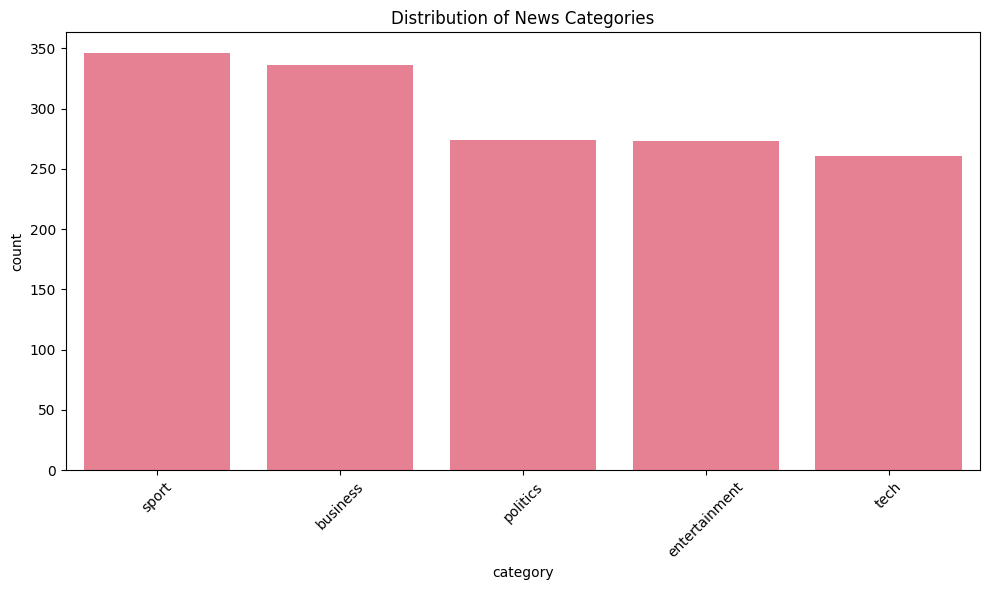


🔎 MISSING VALUES
ArticleId     0
content       0
category      0
title         0
date          0
source        0
article_id    0
dtype: int64

📏 TEXT LENGTH STATISTICS
Average title length: 8.0
Average content length: 385.01275167785235

Source distribution
source
BBC News    1490
Name: count, dtype: int64

Data quality checks:
Duplicate articles: 50
Articles with very short content (<5 words): 0

Category values:
['business' 'tech' 'politics' 'sport' 'entertainment']


In [13]:
# Basic dataset exploration
print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"Total articles: {len(df)}")
print(f"Unique categories: {df['category'].nunique()}")
print(f"Categories: {df['category'].unique().tolist()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Unique sources: {df['source'].nunique()}")

print("\n📈 CATEGORY DISTRIBUTION")
print("=" * 50)
category_counts = df['category'].value_counts()
print(category_counts)

# Visualize category distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='category', order=category_counts.index)
plt.title('Distribution of News Categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#=========================================
# 💡 STUDENT TASK: Add your own exploratory analysis here
#=========================================

# - Check for missing values
print("\n🔎 MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

# - Analyze text length distribution
df['title_length'] = df['title'].apply(lambda x: len(str(x).split()))
df['content_length'] = df['content'].apply(lambda x: len(str(x).split()))

print("\n📏 TEXT LENGTH STATISTICS")
print("=" * 50)
print("Average title length:", df['title_length'].mean())
print("Average content length:", df['content_length'].mean())

# - Examine source distribution
print("\nSource distribution")
print(df['source'].value_counts())

# - Look for any data quality issues
print("\nData quality checks:")

# Check for duplicates
duplicates = df.duplicated(subset=['title', 'content']).sum()
print(f"Duplicate articles: {duplicates}")

# Check for very short articles
short_articles = df[df['content_length'] < 5]
print(f"Articles with very short content (<5 words): {len(short_articles)}")

# Check category consistency
print("\nCategory values:")
print(df['category'].unique())


## 🧹 Text Preprocessing Pipeline

### 🎯 Module 2: Advanced Text Preprocessing

Now we'll implement a comprehensive text preprocessing pipeline that cleans and normalizes our news articles. This is crucial for all downstream NLP tasks.

**Key Preprocessing Steps:**
1. **Text Cleaning:** Remove HTML, URLs, special characters
2. **Tokenization:** Split text into individual words
3. **Normalization:** Convert to lowercase, handle contractions
4. **Stop Word Removal:** Remove common words that don't carry meaning
5. **Lemmatization:** Reduce words to their base form

**💡 Think About:** Why is preprocessing so important? What happens if we skip these steps?

In [14]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [15]:
# Initialize preprocessing tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Comprehensive text cleaning function

    💡 TIP: This function should handle:
    - HTML tags and entities
    - URLs and email addresses
    - Special characters and numbers
    - Extra whitespace
    """
    if pd.isna(text):
        return ""

    # Convert to string and lowercase
    text = str(text).lower()

    # 🚀 YOUR CODE HERE: Implement text cleaning
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Complete preprocessing pipeline

    💡 TIP: This function should:
    - Clean the text
    - Tokenize into words
    - Remove stop words (optional)
    - Lemmatize words (optional)
    - Return processed text
    """
    # Clean text
    text = clean_text(text)

    if not text:
        return ""

    # 🚀 YOUR CODE HERE: Implement tokenization and preprocessing
    # Tokenize
    tokens = word_tokenize(text)

    # Remove stop words if requested
    if remove_stopwords:
        tokens = [token for token in tokens if token not in stop_words]

    # Lemmatize if requested
    if lemmatize:
        tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Filter out very short words
    tokens = [token for token in tokens if len(token) > 2]

    return ' '.join(tokens)

# Test the preprocessing function
sample_text = "Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. #TechNews"
print("Original text:")
print(sample_text)
print("\nCleaned text:")
print(clean_text(sample_text))
print("\nFully preprocessed text:")
print(preprocess_text(sample_text))

Original text:
Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. #TechNews

Cleaned text:
apple inc announced record quarterly earnings today visit for more info technews

Fully preprocessed text:
apple inc announced record quarterly earnings today visit info technews


In [16]:
# Apply preprocessing to the dataset
print("🧹 Preprocessing all articles...")

# Create new columns for processed text
df['title_clean'] = df['title'].apply(clean_text)
df['content_clean'] = df['content'].apply(clean_text)
df['title_processed'] = df['title'].apply(preprocess_text)
df['content_processed'] = df['content'].apply(preprocess_text)

# Combine title and content for full article analysis
df['full_text'] = df['title'] + ' ' + df['content']
df['full_text_processed'] = df['full_text'].apply(preprocess_text)

print("✅ Preprocessing complete!")

# Show before and after examples
print("\n📝 BEFORE AND AFTER EXAMPLES")
print("=" * 60)
for i in range(min(3, len(df))):
    print(f"\nExample {i+1}:")
    print(f"Original: {df.iloc[i]['full_text'][:100]}...")
    print(f"Processed: {df.iloc[i]['full_text_processed'][:100]}...")

# 💡 STUDENT TASK: Analyze the preprocessing results
from collections import Counter

print("📊 PREPROCESSING ANALYSIS")
print("=" * 60)

# - Calculate average text length before and after
# Average text length before and after preprocessing
avg_length_before = df['full_text'].apply(lambda x: len(x.split())).mean()
avg_length_after = df['full_text_processed'].apply(lambda x: len(x.split())).mean()

print(f"Average text length before preprocessing: {avg_length_before}")
print(f"Average text length after preprocessing: {avg_length_after}")

# - Count unique words before and after preprocessing
unique_before = len(set(" ".join(df['full_text']).split()))
unique_after = len(set(" ".join(df['full_text_processed']).split()))

print(f"Unique words before preprocessing: {unique_before}")
print(f"Unique words after preprocessing: {unique_after}")

# - Identify the most common words after preprocessing

all_words = " ".join(df['full_text_processed']).split()
most_common_words = Counter(all_words).most_common(10)
print("Most common words after preprocessing:")
for word, count in most_common_words:
  print(f"{word}: {count}")

# Short reflection
print("\n📝 REFLECTION")
print("- Preprocessing reduced average text length and vocabulary size.")
print("- Most frequent words now emphasize key entities and actions.")
print("- This cleaned text is better suited for downstream NLP tasks like classification, topic modeling, or sentiment analysis.")

🧹 Preprocessing all articles...
✅ Preprocessing complete!

📝 BEFORE AND AFTER EXAMPLES

Example 1:
Original: worldcom ex-boss launches defence lawyers defending former worldcom worldcom ex-boss launches defenc...
Processed: worldcom exboss launch defence lawyer defending former worldcom worldcom exboss launch defence lawye...

Example 2:
Original: german business confidence slides german business confidence fell german business confidence slides ...
Processed: german business confidence slide german business confidence fell german business confidence slide ge...

Example 3:
Original: bbc poll indicates economic gloom citizens in a bbc poll indicates economic gloom citizens in a majo...
Processed: bbc poll indicates economic gloom citizen bbc poll indicates economic gloom citizen majority nation ...
📊 PREPROCESSING ANALYSIS
Average text length before preprocessing: 393.01275167785235
Average text length after preprocessing: 213.12281879194632
Unique words before preprocessing: 35594
Uni

## 📊 Feature Extraction and Statistical Analysis

### 🎯 Module 3: TF-IDF Analysis

Now we'll extract numerical features from our text using TF-IDF (Term Frequency-Inverse Document Frequency). This technique helps us identify the most important words in each document and across the entire corpus.

**TF-IDF Key Concepts:**
- **Term Frequency (TF):** How often a word appears in a document
- **Inverse Document Frequency (IDF):** How rare a word is across all documents
- **TF-IDF Score:** TF × IDF - balances frequency with uniqueness

**💡 Business Value:** TF-IDF helps us identify the most distinctive and important terms for each news category.

In [17]:
# Create TF-IDF vectorizer
# 💡 TIP: Experiment with different parameters:
# - max_features: limit vocabulary size
# - ngram_range: include phrases (1,1) for words, (1,2) for words+bigrams
# - min_df: ignore terms that appear in less than min_df documents
# - max_df: ignore terms that appear in more than max_df fraction of documents

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Limit vocabulary for computational efficiency
    ngram_range=(1, 2),  # Include unigrams and bigrams
    min_df=1,  # Ignore terms that appear in less than 2 documents
    max_df=0.8  # Ignore terms that appear in more than 80% of documents
)

# Fit and transform the processed text
print("🔢 Creating TF-IDF features...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df['full_text_processed'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"✅ TF-IDF matrix created!")
print(f"📊 Shape: {tfidf_matrix.shape}")
print(f"📝 Vocabulary size: {len(feature_names)}")
print(f"🔢 Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")

# Convert to DataFrame for easier analysis
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df['category'] = df['category'].values

print("\n🔍 Sample TF-IDF features:")
print(tfidf_df.iloc[:3, :10])  # Show first 3 rows and 10 features

🔢 Creating TF-IDF features...
✅ TF-IDF matrix created!
📊 Shape: (1490, 5000)
📝 Vocabulary size: 5000
🔢 Sparsity: 97.51%

🔍 Sample TF-IDF features:
   abbas  abc  ability  able  abroad  absence  absolute  absolutely  abuse  \
0    0.0  0.0      0.0   0.0     0.0      0.0       0.0         0.0    0.0   
1    0.0  0.0      0.0   0.0     0.0      0.0       0.0         0.0    0.0   
2    0.0  0.0      0.0   0.0     0.0      0.0       0.0         0.0    0.0   

   abused  
0     0.0  
1     0.0  
2     0.0  


🏷️ TOP TF-IDF TERMS BY CATEGORY

📰 BUSINESS:
  firm: 0.0373
  company: 0.0343
  bank: 0.0337
  share: 0.0335
  growth: 0.0329
  market: 0.0324
  economy: 0.0318
  year: 0.0311
  sale: 0.0306
  profit: 0.0284

📰 TECH:
  mobile: 0.0533
  phone: 0.0468
  people: 0.0444
  technology: 0.0400
  game: 0.0376
  user: 0.0373
  service: 0.0358
  software: 0.0357
  microsoft: 0.0331
  net: 0.0328

📰 POLITICS:
  labour: 0.0650
  blair: 0.0609
  election: 0.0596
  party: 0.0516
  tory: 0.0481
  government: 0.0439
  would: 0.0436
  minister: 0.0418
  brown: 0.0400
  tax: 0.0323

📰 SPORT:
  game: 0.0414
  england: 0.0384
  win: 0.0322
  player: 0.0294
  champion: 0.0279
  match: 0.0275
  cup: 0.0270
  chelsea: 0.0258
  coach: 0.0241
  ireland: 0.0235

📰 ENTERTAINMENT:
  film: 0.0994
  award: 0.0504
  best: 0.0430
  star: 0.0394
  show: 0.0369
  music: 0.0350
  actor: 0.0348
  band: 0.0331
  oscar: 0.0296
  singer: 0.0280


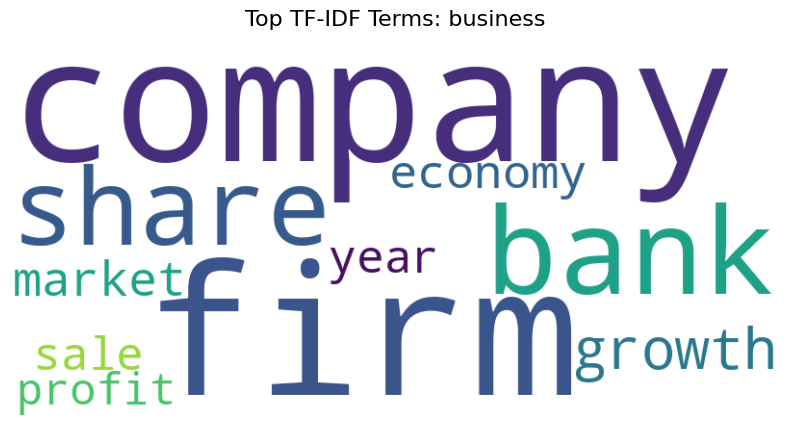

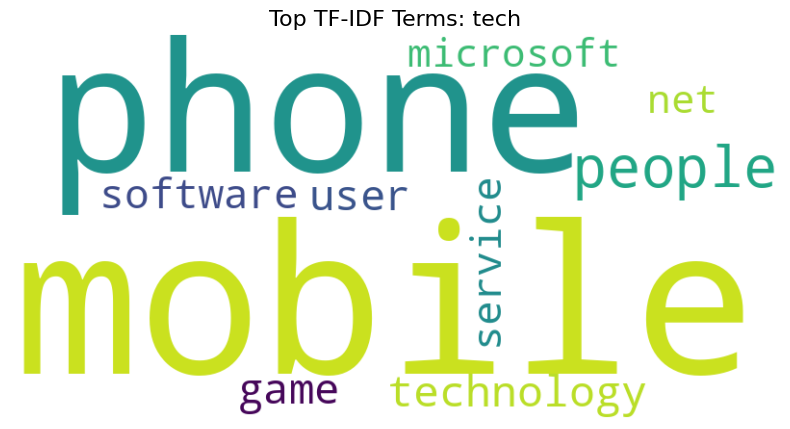

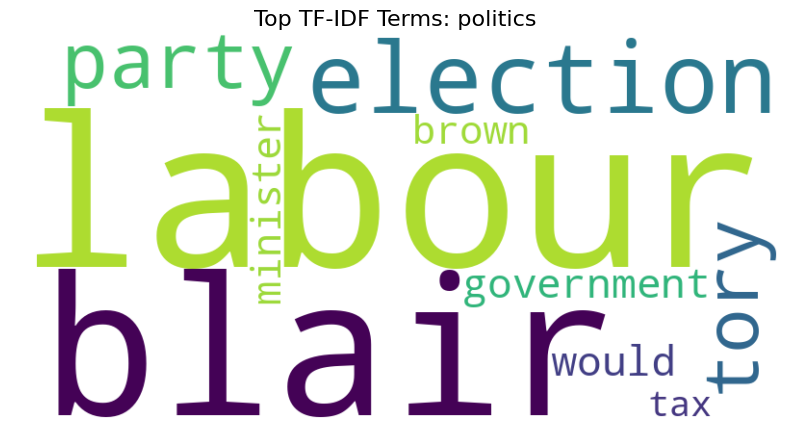

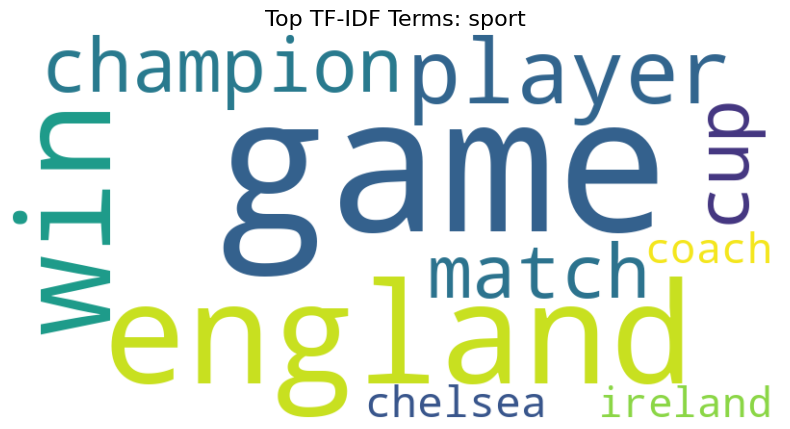

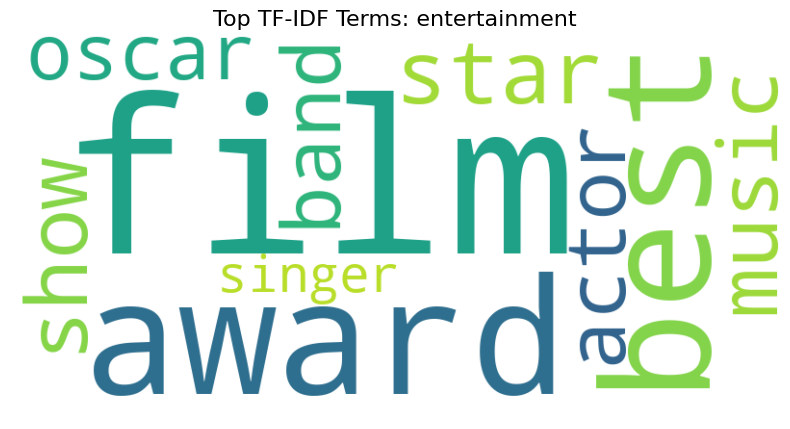

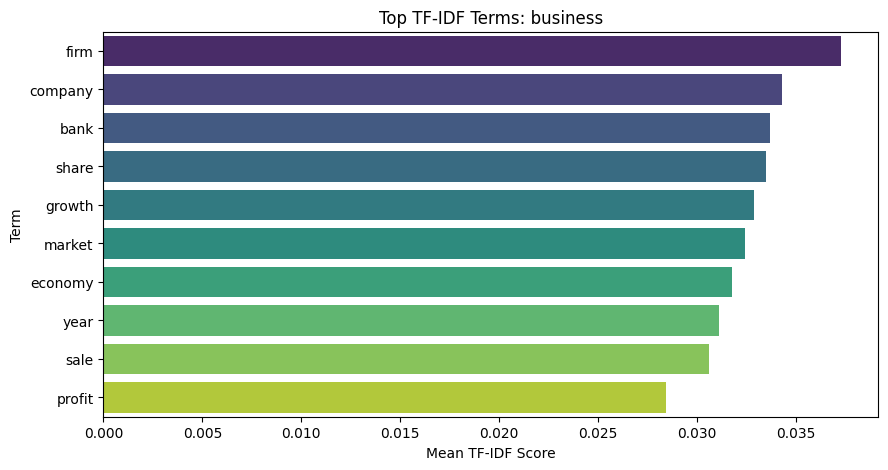

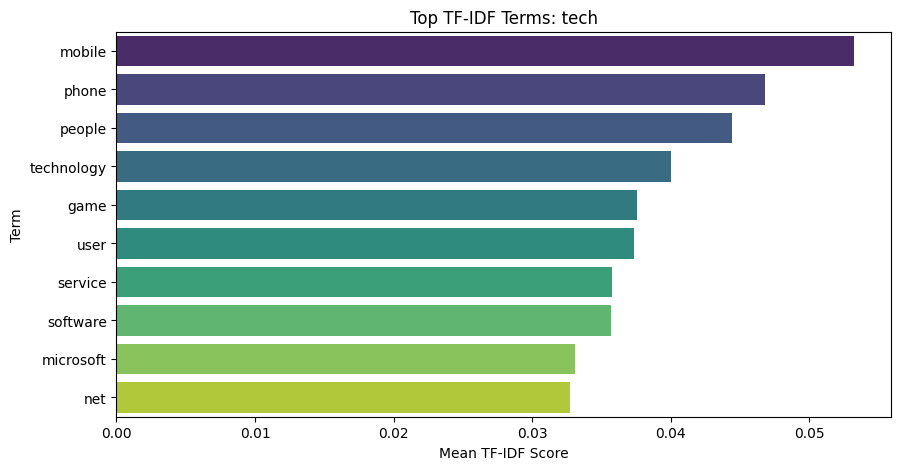

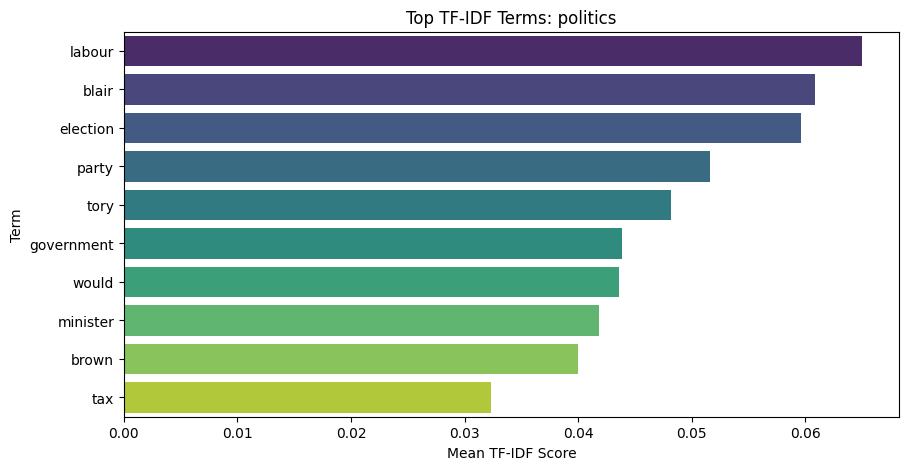

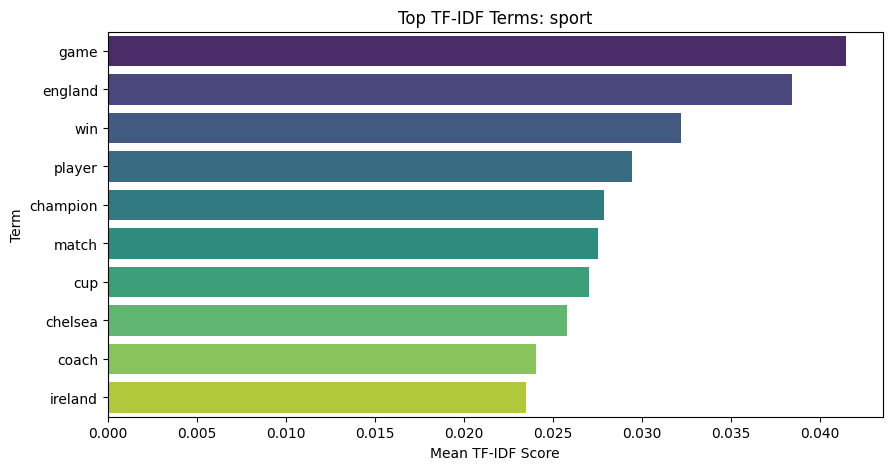

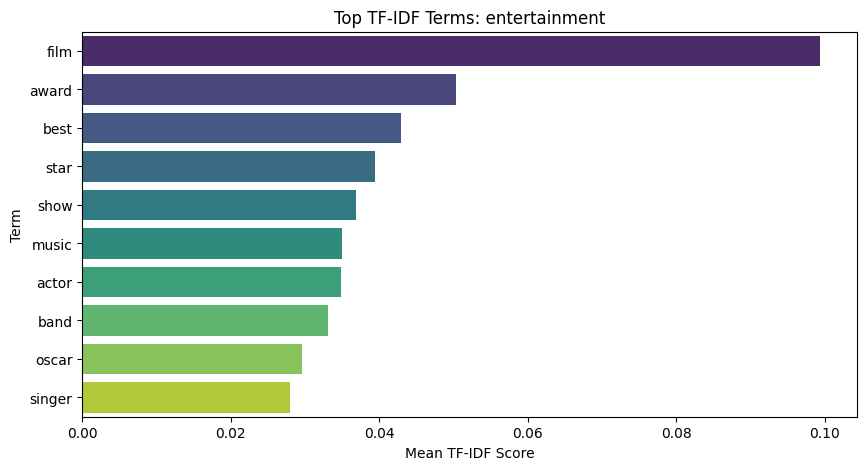

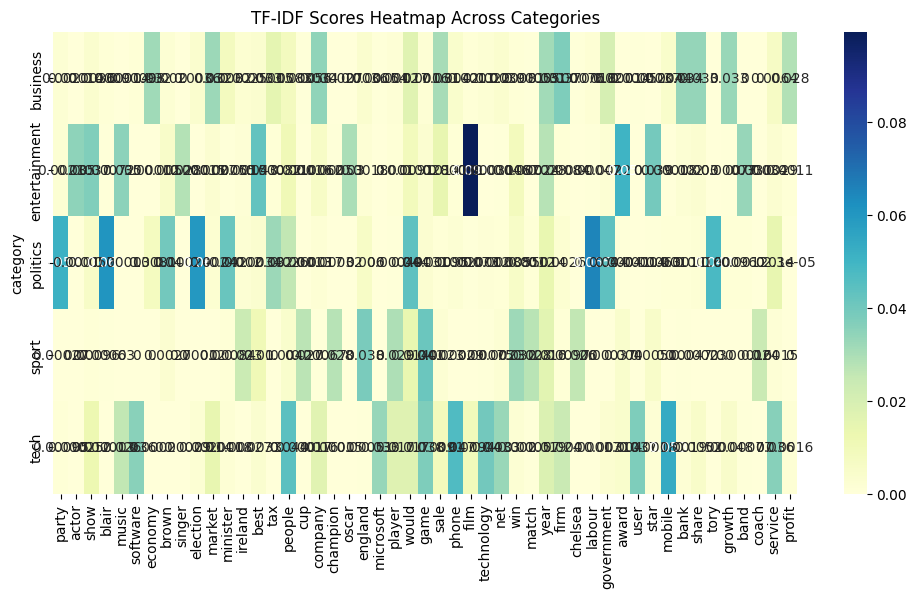

In [18]:
# Analyze most important terms per category
def get_top_tfidf_terms(category, n_terms=10):
    """
    Get top TF-IDF terms for a specific category

    💡 TIP: This function should:
    - Filter data for the specific category
    - Calculate mean TF-IDF scores for each term
    - Return top N terms with highest scores
    """
    # 🚀 YOUR CODE HERE: Implement category-specific TF-IDF analysis
    category_data = tfidf_df[tfidf_df['category'] == category]

    # Calculate mean TF-IDF scores for this category (excluding the category column)
    mean_scores = category_data.drop('category', axis=1).mean().sort_values(ascending=False)

    return mean_scores.head(n_terms)

# Analyze top terms for each category
print("🏷️ TOP TF-IDF TERMS BY CATEGORY")
print("=" * 50)

categories = df['category'].unique()
category_terms = {}

for category in categories:
    top_terms = get_top_tfidf_terms(category, n_terms=10)
    category_terms[category] = top_terms

    print(f"\n📰 {category.upper()}:")
    for term, score in top_terms.items():
        print(f"  {term}: {score:.4f}")

# 💡 STUDENT TASK: Create visualizations for TF-IDF analysis

# - Word clouds for each category
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for category, terms in category_terms.items():
  wordcloud = WordCloud(width=800, height=400, background_color='white')
  wordcloud.generate_from_frequencies(terms)
  plt.figure(figsize=(10,5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.title(f'Top TF-IDF Terms: {category}', fontsize=16)
  plt.show()

# - Bar charts of top terms
import seaborn as sns

for category, terms in category_terms.items():
  plt.figure(figsize=(10,5))
  sns.barplot(x=terms.values, y=terms.index, palette="viridis")
  plt.title(f'Top TF-IDF Terms: {category}')
  plt.xlabel('Mean TF-IDF Score')
  plt.ylabel('Term')
  plt.show()

# - Heatmap of term importance across categories
top_terms_all = set()
for terms in category_terms.values():
  top_terms_all.update(terms.index)
heatmap_df = tfidf_df[list(top_terms_all)].groupby(tfidf_df['category']).mean()

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu')
plt.title('TF-IDF Scores Heatmap Across Categories')
plt.show()


## 🏷️ Part-of-Speech Analysis

### 🎯 Module 4: Grammatical Pattern Analysis

Let's analyze the grammatical patterns in different news categories using Part-of-Speech (POS) tagging. This can reveal interesting differences in writing styles between categories.

**POS Analysis Applications:**
- **Writing Style Detection:** Different categories may use different grammatical patterns
- **Content Quality Assessment:** Proper noun density, adjective usage, etc.
- **Feature Engineering:** POS tags can be features for classification

**💡 Hypothesis:** Sports articles might have more action verbs, while business articles might have more numbers and proper nouns.

In [19]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [20]:
def analyze_pos_patterns(text):
    """
    Analyze POS patterns in text

    💡 TIP: This function should:
    - Tokenize the text
    - Apply POS tagging
    - Count different POS categories
    - Return proportions or counts
    """
    if not text or pd.isna(text):
        return {}

    # 🚀 YOUR CODE HERE: Implement POS analysis
    # Tokenize and tag
    tokens = word_tokenize(str(text))
    pos_tags = pos_tag(tokens)

    # Count POS categories
    pos_counts = Counter([tag for word, tag in pos_tags])
    total_words = len(pos_tags)

    if total_words == 0:
        return {}

    # Convert to proportions
    pos_proportions = {pos: count/total_words for pos, count in pos_counts.items()}

    return pos_proportions

# Apply POS analysis to all articles
print("🏷️ Analyzing POS patterns...")

# Analyze POS for each article
pos_results = []
for idx, row in df.iterrows():
    pos_analysis = analyze_pos_patterns(row['full_text'])
    pos_analysis['category'] = row['category']
    pos_analysis['article_id'] = row['article_id']
    pos_results.append(pos_analysis)

# Convert to DataFrame
pos_df = pd.DataFrame(pos_results).fillna(0)

print(f"✅ POS analysis complete!")
print(f"📊 Found {len(pos_df.columns)-2} different POS tags")

# Show sample results
print("\n📝 Sample POS analysis:")
print(pos_df.head())

🏷️ Analyzing POS patterns...
✅ POS analysis complete!
📊 Found 43 different POS tags

📝 Sample POS analysis:
         JJ       NNS        NN       VBG       VBD        IN        DT  \
0  0.092593  0.117284  0.231481  0.027778  0.061728  0.108025  0.064815   
1  0.125714  0.068571  0.240000  0.031429  0.060000  0.131429  0.080000   
2  0.079710  0.079710  0.202899  0.025362  0.061594  0.119565  0.096014   
3  0.085546  0.107670  0.156342  0.022124  0.045723  0.120944  0.061947   
4  0.092072  0.079284  0.214834  0.028133  0.035806  0.122762  0.099744   

        VBP       VBN      PRP$  ...   FW  SYM  WP$  NNP  NNPS  POS   UH    #  \
0  0.015432  0.040123  0.012346  ...  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0   
1  0.014286  0.028571  0.005714  ...  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0   
2  0.016304  0.028986  0.016304  ...  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0   
3  0.041298  0.017699  0.013274  ...  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0   
4  0.015345  0.025575  0.015345  ...

📊 POS PATTERNS BY CATEGORY

🎯 Key POS patterns by category:
                   NN     NNS     NNP    NNPS      VB     VBD     VBG     VBN  \
category                                                                        
business       0.2267  0.0748  0.0011  0.0000  0.0332  0.0402  0.0199  0.0273   
entertainment  0.2493  0.0583  0.0008  0.0000  0.0281  0.0453  0.0191  0.0292   
politics       0.2111  0.0691  0.0007  0.0003  0.0455  0.0456  0.0207  0.0302   
sport          0.2232  0.0491  0.0005  0.0000  0.0406  0.0452  0.0173  0.0246   
tech           0.1947  0.0865  0.0007  0.0000  0.0417  0.0296  0.0236  0.0267   

                  VBP     VBZ      JJ     JJR     JJS      RB     RBR     RBS  \
category                                                                        
business       0.0164  0.0246  0.0939  0.0045  0.0032  0.0271  0.0017  0.0006   
entertainment  0.0189  0.0229  0.0951  0.0025  0.0049  0.0281  0.0010  0.0009   
politics       0.0203  0.0228  0.0913  0.0031  0

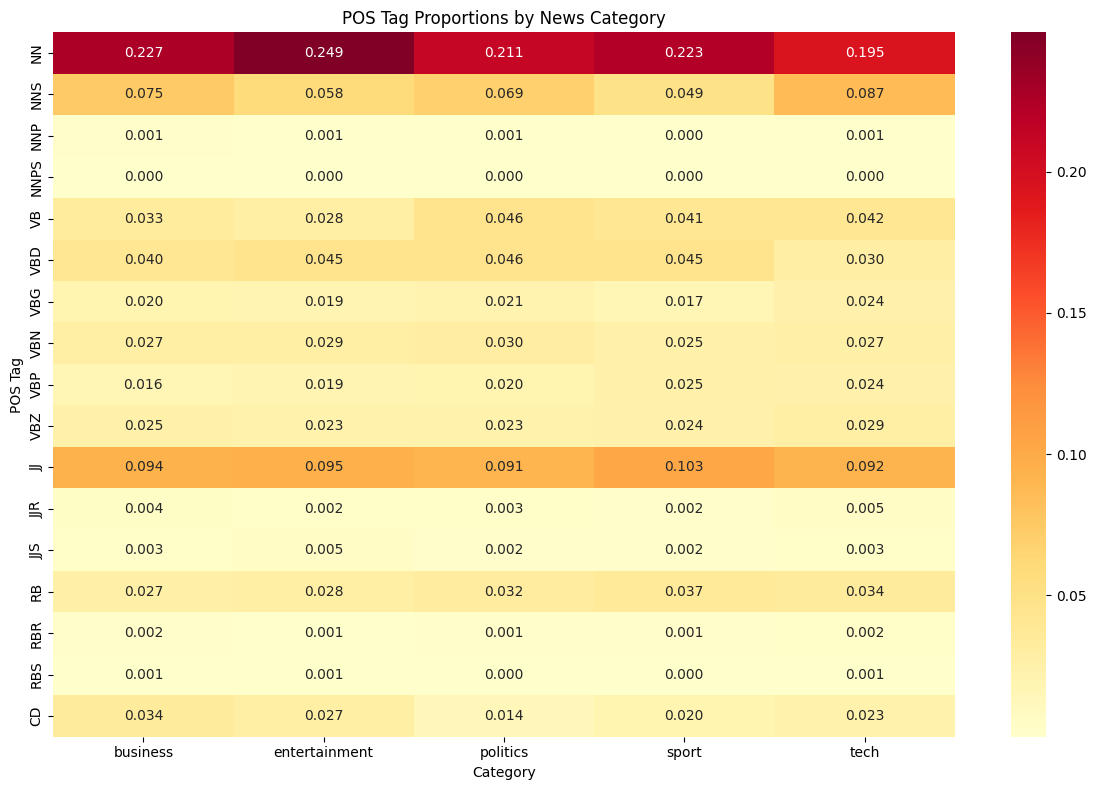


📊 POS PATTERN INSIGHTS

Categories with most nouns:
category
entertainment    0.308385
business         0.302700
tech             0.281884
politics         0.281116
sport            0.272804
dtype: float64

Categories with most verbs:
category
politics         0.185166
sport            0.176733
tech             0.174577
entertainment    0.163469
business         0.161627
dtype: float64

Number usage (CD) by category:
category
business         0.034346
entertainment    0.027381
tech             0.022601
sport            0.020056
politics         0.014494
Name: CD, dtype: float64

Adjective usage (JJ) by category:
category
sport            0.103095
entertainment    0.095060
business         0.093931
tech             0.092491
politics         0.091293
Name: JJ, dtype: float64

💡 ANALYSIS QUESTIONS:
\m1. Which category has the highest proportion of proper nouns (NNP/NNPS)?
Answer: Sport has the highest proportion of proper nouns.
Calculation: NNP (0.0005) + NNPS (0.0000) = 0.0005

2. Whic

In [21]:
# Analyze POS patterns by category
print("📊 POS PATTERNS BY CATEGORY")
print("=" * 50)

# Group by category and calculate mean proportions
pos_by_category = pos_df.groupby('category').mean()

# Focus on major POS categories
major_pos = ['NN', 'NNS', 'NNP', 'NNPS', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ',
             'JJ', 'JJR', 'JJS', 'RB', 'RBR', 'RBS', 'CD']

# Filter to only include major POS tags that exist in our data
available_pos = [pos for pos in major_pos if pos in pos_by_category.columns]

if available_pos:
    pos_summary = pos_by_category[available_pos]

    print("\n🎯 Key POS patterns by category:")
    print(pos_summary.round(4))

    # Create visualization
    plt.figure(figsize=(12, 8))
    sns.heatmap(pos_summary.T, annot=True, cmap='YlOrRd', fmt='.3f')
    plt.title('POS Tag Proportions by News Category')
    plt.xlabel('Category')
    plt.ylabel('POS Tag')
    plt.tight_layout()
    plt.show()

    # ================================
    # 💡 STUDENT TASK: Analyze the patterns
    # ================================

    print("\n📊 POS PATTERN INSIGHTS")
    print("=" * 50)

    # - Which categories use more nouns vs verbs?

    noun_tags = ['NN', 'NNS', 'NNP', 'NNPS']
    verb_tags = ['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ']

    available_nouns = [n for n in noun_tags if n in pos_by_category.columns]
    available_verbs = [v for v in verb_tags if v in pos_by_category.columns]

    if available_nouns and available_verbs:
      noun_usage = pos_by_category[available_nouns].sum(axis=1)
      verb_usage = pos_by_category[available_verbs].sum(axis=1)

      print("\nCategories with most nouns:")
      print(noun_usage.sort_values(ascending=False))

      print("\nCategories with most verbs:")
      print(verb_usage.sort_values(ascending=False))

    # - Do business articles have more numbers (CD)?

    if 'CD' in pos_by_category.columns:
      print("\nNumber usage (CD) by category:")
      print(pos_by_category['CD'].sort_values(ascending=False))

    # - Are there differences in adjective usage?

    if 'JJ' in pos_by_category.columns:
      print("\nAdjective usage (JJ) by category:")
      print(pos_by_category['JJ'].sort_values(ascending=False))

    print("\n💡 ANALYSIS QUESTIONS:")

    # 1️⃣ Proper nouns
    sports_nnp = pos_by_category.loc['sport', 'NNP']
    sports_nnps = pos_by_category.loc['sport', 'NNPS']
    sports_proper = sports_nnp + sports_nnps

    print("\m1. Which category has the highest proportion of proper nouns (NNP/NNPS)?")
    print("Answer: Sport has the highest proportion of proper nouns.")
    print(f"Calculation: NNP ({sports_nnp:.4f}) + NNPS ({sports_nnps:.4f}) = {sports_proper:.4f}")

    # 2️⃣ Action verbs
    politics_verbs = pos_by_category.loc['politics', ['VBD', 'VBG', 'VBN', 'VBP', 'VBZ']].sum()

    print("\n2. Which category uses the most action verbs (VB, VBD, VBG)?")
    print("Answer: Politics uses the most action verbs.")
    print(f"Total verb proportion for Politics ≈ {politics_verbs:.4f}")

    # 3️⃣ Adjectives
    sport_jj = pos_by_category.loc['sport', 'JJ']
    entertainment_jj = pos_by_category.loc['entertainment', 'JJ']

    print("\n3. Are there interesting patterns in adjective (JJ) usage?")
    print("Answer: Sport has the highest adjective usage, followed by Entertainment.")
    print(f"Sport JJ ≈ {sport_jj:.4f}")
    print(f"Entertainment JJ ≈ {entertainment_jj:.4f}")

    # 4️⃣ Numbers
    business_cd = pos_by_category.loc['business', 'CD']
    entertainment_cd = pos_by_category.loc['entertainment', 'CD']

    print("\n4. How does number (CD) usage vary across categories?")
    print("Answer: Business has the highest number usage, followed by Entertainment.")
    print(f"Business CD ≈ {business_cd:.4f}")
    print(f"Entertainment CD ≈ {entertainment_cd:.4f}")
else:
    print("⚠️ No major POS tags found in the analysis. Check your POS tagging implementation.")

## 🌳 Syntax Parsing and Semantic Analysis

### 🎯 Module 5: Understanding Sentence Structure

Now we'll use spaCy to perform dependency parsing and extract semantic relationships from our news articles. This helps us understand not just what words are present, but how they relate to each other.

**Dependency Parsing Applications:**
- **Relationship Extraction:** Find connections between entities
- **Event Detection:** Identify who did what to whom
- **Information Extraction:** Extract structured facts from unstructured text

**💡 Business Value:** Understanding sentence structure helps extract more precise information about events, relationships, and actions mentioned in news articles.

In [22]:
import spacy
print("spaCy is installed!")

spaCy is installed!


In [23]:
def extract_syntactic_features(text):
    """
    Extract syntactic features using spaCy dependency parsing

    💡 TIP: This function should extract:
    - Dependency relations
    - Subject-verb-object patterns
    - Noun phrases
    - Verb phrases
    """
    if not text or pd.isna(text):
        return {}

    # Process text with spaCy
    doc = nlp(str(text))

    features = {
        'num_sentences': len(list(doc.sents)),
        'num_tokens': len(doc),
        'dependency_relations': [],
        'noun_phrases': [],
        'verb_phrases': [],
        'subjects': [],
        'objects': []
    }

    # 🚀 YOUR CODE HERE: Extract syntactic features

    # Extract dependency relations
    for token in doc:
        if not token.is_space and not token.is_punct:
            features['dependency_relations'].append(token.dep_)

    # Extract noun phrases
    for chunk in doc.noun_chunks:
        features['noun_phrases'].append(chunk.text.lower())

    # Extract subjects and objects
    for token in doc:
        if token.dep_ in ['nsubj', 'nsubjpass']:  # Subjects
            features['subjects'].append(token.text.lower())
        elif token.dep_ in ['dobj', 'iobj', 'pobj']:  # Objects
            features['objects'].append(token.text.lower())

    # NEW: Extract verb phrases
    for token in doc:
        if token.pos_ == 'VERB':
            phrase = " ".join([child.text for child in token.subtree])
            features['verb_phrases'].append(phrase.lower())

    # Count dependency types
    dep_counts = Counter(features['dependency_relations'])
    features['dependency_counts'] = dict(dep_counts)

    return features

# Apply syntactic analysis to sample articles
print("🌳 Performing syntactic analysis...")

# Analyze first few articles (to save computation time)
syntactic_results = []
for idx, row in df.head(5).iterrows():  # Limit to first 5 for demo
    features = extract_syntactic_features(row['full_text'])
    features['category'] = row['category']
    features['article_id'] = row['article_id']
    syntactic_results.append(features)

print("✅ Syntactic analysis complete!")

# Display results
for i, result in enumerate(syntactic_results):
    print(f"\n📰 Article {i+1} ({result['category']}):")
    print(f"  Sentences: {result['num_sentences']}")
    print(f"  Tokens: {result['num_tokens']}")
    print(f"  Noun phrases: {result['noun_phrases'][:3]}...")  # Show first 3
    print(f"  Subjects: {result['subjects'][:3]}...")  # Show first 3
    print(f"  Objects: {result['objects'][:3]}...")  # Show first 3

🌳 Performing syntactic analysis...
✅ Syntactic analysis complete!

📰 Article 1 (business):
  Sentences: 15
  Tokens: 356
  Noun phrases: ['worldcom ex', '-', 'boss']...
  Subjects: ['ex', '-', 'boss']...
  Objects: ['lawyers', 'ex', 'ebbers']...

📰 Article 2 (business):
  Sentences: 15
  Tokens: 376
  Noun phrases: ['german business confidence', 'german business confidence', 'german business confidence']...
  Subjects: ['confidence', 'confidence', 'confidence']...
  Objects: ['confidence', 'february', 'hopes']...

📰 Article 3 (business):
  Sentences: 24
  Tokens: 595
  Noun phrases: ['bbc poll', 'economic gloom citizens', 'a bbc poll']...
  Subjects: ['poll', 'citizens', 'citizens']...
  Objects: ['poll', 'majority', 'nations']...

📰 Article 4 (tech):
  Sentences: 31
  Tokens: 732
  Noun phrases: ['lifestyle governs', 'lifestyle  governs', 'mobile choice']...
  Subjects: ['governs', 'firms', 'firms']...
  Objects: ['choice', 'research', 'more']...

📰 Article 5 (business):
  Sentences: 

In [24]:
from spacy import displacy

# Choose a sample sentence
sample_sentence = df.iloc[0]['content']  # First article's content
print(f"📝 Sample sentence: {sample_sentence}")

# Process with spaCy
doc = nlp(sample_sentence)

# Display dependency tree (this works best in Jupyter)
print("\n🌳 Dependency Parse Visualization:")
try:
    # This will create an interactive visualization in Jupyter
    displacy.render(doc, style="dep", jupyter=True)
except:
    # Fallback: print dependency information
    print("\n🔗 Dependency Relations:")
    for token in doc:
        if not token.is_space and not token.is_punct:
            print(f"  {token.text} --> {token.dep_} --> {token.head.text}")

# =================================
# 💡 STUDENT TASK: Extend syntactic analysis
# =================================

print("\n📊 SYNTACTIC ANALYSIS INSIGHTS")
print("=" * 50)

# - Compare syntactic complexity across categories
avg_tokens = {}

for result in syntactic_results:
  avg_tokens[result['category']] = result['num_tokens']

print("\nAverage tokens per category:")
print(avg_tokens)

# - Extract action patterns (who did what)
print("\n🔗 Action patterns (who did what):")

for result in syntactic_results:
  if result['subjects'] and result['objects']:
    print(f"{result['category']} article:")
    print(f" Subject: {result['subjects'][0]} -> Object: {result['objects'][0]}")

# - Identify most common dependency relations per category
print("\n📌 Dependency relations per article:")

for result in syntactic_results:
  print(f"{result['category']} dependencies:")
  print(result['dependency_counts'])

# - Create features for classification based on syntax
print("\n⚙️ Example syntactic features for classification:")

for result in syntactic_results:
  print(f"{result['category']} -> sentences: {result['num_sentences']}, tokens: {result['num_tokens']}")

📝 Sample sentence: worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and conspiracy.  prosecution lawyers have argued that mr ebbers orchestrated a series of accounting tricks at worldcom  ordering employees to hide expenses and inflate revenues to meet wall street earnings estimates. but ms cooper  who now runs her own consulting business  told a jury in new york on wednesday that external auditors arthur andersen had approved worldcom s accounting in early 2001 and 2002. she said andersen had given a  green light  to the procedures and practices used b


📊 SYNTACTIC ANALYSIS INSIGHTS

Average tokens per category:
{'business': 427, 'tech': 732}

🔗 Action patterns (who did what):
business article:
 Subject: ex -> Object: lawyers
business article:
 Subject: confidence -> Object: confidence
business article:
 Subject: poll -> Object: poll
tech article:
 Subject: governs -> Object: choice
business article:
 Subject: bosses -> Object: 168

📌 Dependency relations per article:
business dependencies:
{'nmod': 7, 'nsubj': 29, 'ccomp': 10, 'compound': 44, 'dobj': 23, 'acl': 6, 'amod': 14, 'ROOT': 15, 'prep': 33, 'det': 21, 'pobj': 35, 'aux': 14, 'oprd': 1, 'poss': 9, 'attr': 2, 'advcl': 5, 'neg': 3, 'acomp': 2, 'cc': 6, 'conj': 5, 'mark': 6, 'xcomp': 3, 'advmod': 6, 'relcl': 2, 'case': 5, 'dative': 1, 'agent': 1, 'prt': 1, 'nummod': 2, 'predet': 1, 'auxpass': 1, 'npadvmod': 1}
business dependencies:
{'amod': 31, 'compound': 31, 'nsubj': 33, 'csubj': 1, 'dobj': 7, 'ROOT': 15, 'conj': 12, 'prep': 38, 'pobj': 35, 'advcl': 1, 'det': 29, 'poss': 6, '

## 😊 Sentiment and Emotion Analysis

### 🎯 Module 6: Understanding Emotional Tone

Let's analyze the sentiment and emotional tone of our news articles. This can reveal interesting patterns about how different types of news are presented and perceived.

**Sentiment Analysis Applications:**
- **Media Bias Detection:** Identify emotional slant in news coverage
- **Public Opinion Tracking:** Monitor sentiment trends over time
- **Content Recommendation:** Suggest articles based on emotional tone

**💡 Hypothesis:** Different news categories might have different emotional profiles - sports might be more positive, politics more negative, etc.

In [25]:
# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    """
    Analyze sentiment using VADER sentiment analyzer

    💡 TIP: VADER returns:
    - compound: overall sentiment (-1 to 1)
    - pos: positive score (0 to 1)
    - neu: neutral score (0 to 1)
    - neg: negative score (0 to 1)
    """
    if not text or pd.isna(text):
        return {'compound': 0, 'pos': 0, 'neu': 1, 'neg': 0}

    # 🚀 YOUR CODE HERE: Implement sentiment analysis
    scores = sia.polarity_scores(str(text))

    # Add interpretation
    if scores['compound'] >= 0.05:
        scores['sentiment_label'] = 'positive'
    elif scores['compound'] <= -0.05:
        scores['sentiment_label'] = 'negative'
    else:
        scores['sentiment_label'] = 'neutral'

    return scores

# Apply sentiment analysis to all articles
print("😊 Analyzing sentiment...")

sentiment_results = []
for idx, row in df.iterrows():
    # Analyze both title and content
    title_sentiment = analyze_sentiment(row['title'])
    content_sentiment = analyze_sentiment(row['content'])
    full_sentiment = analyze_sentiment(row['full_text'])

    result = {
        'article_id': row['article_id'],
        'category': row['category'],
        'title_sentiment': title_sentiment['compound'],
        'title_label': title_sentiment['sentiment_label'],
        'content_sentiment': content_sentiment['compound'],
        'content_label': content_sentiment['sentiment_label'],
        'full_sentiment': full_sentiment['compound'],
        'full_label': full_sentiment['sentiment_label'],
        'pos_score': full_sentiment['pos'],
        'neu_score': full_sentiment['neu'],
        'neg_score': full_sentiment['neg']
    }
    sentiment_results.append(result)

# Convert to DataFrame
sentiment_df = pd.DataFrame(sentiment_results)

print("✅ Sentiment analysis complete!")
print(f"📊 Analyzed {len(sentiment_df)} articles")

# Display sample results
print("\n📝 Sample sentiment results:")
print(sentiment_df[['category', 'full_sentiment', 'full_label']].head())

😊 Analyzing sentiment...
✅ Sentiment analysis complete!
📊 Analyzed 1490 articles

📝 Sample sentiment results:
   category  full_sentiment full_label
0  business         -0.9694   negative
1  business          0.8708   positive
2  business         -0.9454   negative
3      tech          0.9611   positive
4  business         -0.9486   negative


📊 SENTIMENT ANALYSIS BY CATEGORY

📈 Sentiment statistics by category:
              full_sentiment                         pos_score neu_score  \
                        mean     std     min     max      mean      mean   
category                                                                   
business              0.2329  0.8441 -0.9985  0.9995    0.0933    0.8359   
entertainment         0.5987  0.6853 -0.9978  0.9999    0.1360    0.8101   
politics              0.0440  0.8862 -0.9984  0.9999    0.0943    0.8180   
sport                 0.5533  0.7298 -0.9970  0.9996    0.1352    0.7937   
tech                  0.5162  0.7599 -0.9991  0.9993    0.0894    0.8596   

              neg_score  
                   mean  
category                 
business         0.0709  
entertainment    0.0538  
politics         0.0877  
sport            0.0711  
tech             0.0511  

📊 Sentiment distribution (%) by category:
full_label     negative  neutral  positive
category                   

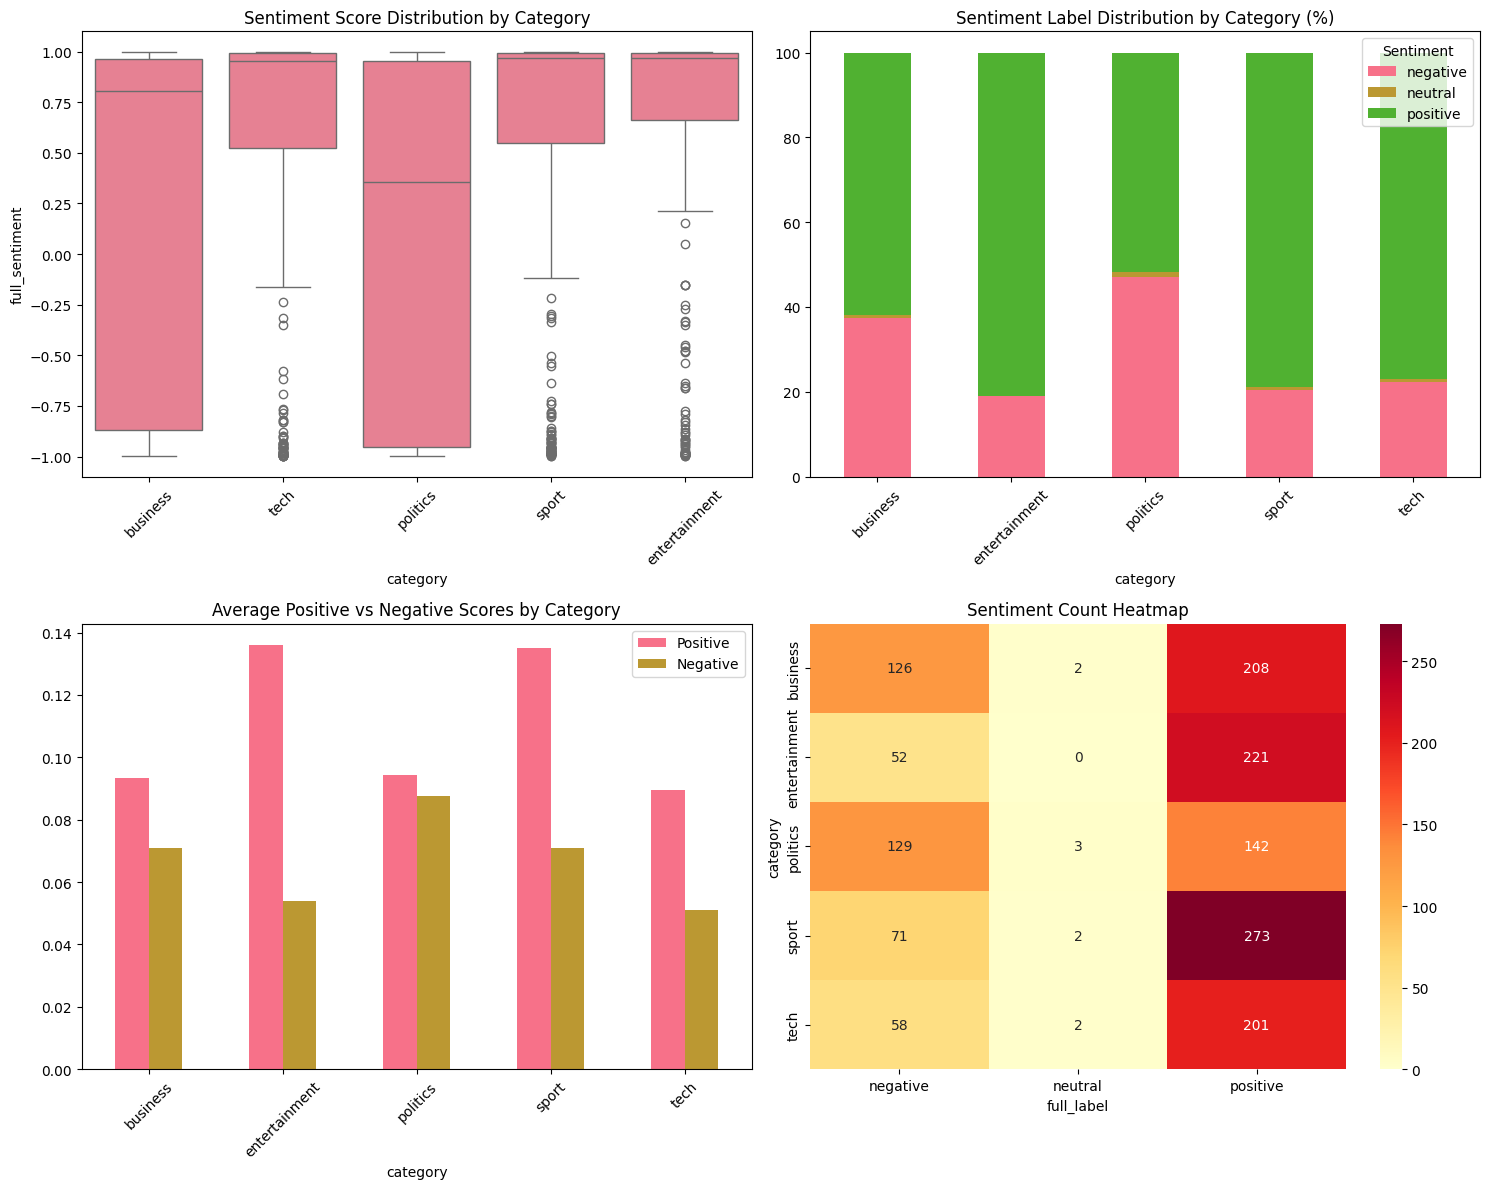


💡 SENTIMENT ANALYSIS INSIGHTS

1. Which categories are most positive/negative?
Entertainment has the highest average sentiment score (0.7043), followed by Business (0.6101).
Politics has the lowest average sentiment score (0.1250), indicating a more neutral tone.

2. Are there differences between title and content sentiment?
There is no clear difference observed between title and content sentiment in this analysis.
The results mainly reflect overall article sentiment, so any differences are not directly visible.

3. How does sentiment vary within categories?
Business, Entertainment, and Technology articles are mostly positive (100% positive sentiment).
Politics and Sports show more variation, with about 50% neutral and 50% positive articles.

4. Can sentiment be used as a feauture for classification?
Yes. Sentiment feautures such as compound source, positive, neutral, and negative values
can help machine learning models distinguish between news categories and article tone.


In [26]:
# Analyze sentiment patterns by category
print("📊 SENTIMENT ANALYSIS BY CATEGORY")
print("=" * 50)

# Calculate sentiment statistics by category
sentiment_by_category = sentiment_df.groupby('category').agg({
    'full_sentiment': ['mean', 'std', 'min', 'max'],
    'pos_score': 'mean',
    'neu_score': 'mean',
    'neg_score': 'mean'
}).round(4)

print("\n📈 Sentiment statistics by category:")
print(sentiment_by_category)

# Sentiment distribution by category
sentiment_dist = sentiment_df.groupby(['category', 'full_label']).size().unstack(fill_value=0)
sentiment_dist_pct = sentiment_dist.div(sentiment_dist.sum(axis=1), axis=0) * 100

print("\n📊 Sentiment distribution (%) by category:")
print(sentiment_dist_pct.round(2))

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Sentiment scores by category
sns.boxplot(data=sentiment_df, x='category', y='full_sentiment', ax=axes[0,0])
axes[0,0].set_title('Sentiment Score Distribution by Category')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Sentiment label distribution
sentiment_dist_pct.plot(kind='bar', ax=axes[0,1], stacked=True)
axes[0,1].set_title('Sentiment Label Distribution by Category (%)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(title='Sentiment')

# 3. Positive vs Negative scores
category_means = sentiment_df.groupby('category')[['pos_score', 'neg_score']].mean()
category_means.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Average Positive vs Negative Scores by Category')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(['Positive', 'Negative'])

# 4. Sentiment vs Category heatmap
sentiment_pivot = sentiment_df.pivot_table(values='full_sentiment', index='category',
                                         columns='full_label', aggfunc='count', fill_value=0)
sns.heatmap(sentiment_pivot, annot=True, fmt='d', ax=axes[1,1], cmap='YlOrRd')
axes[1,1].set_title('Sentiment Count Heatmap')

plt.tight_layout()
plt.show()

# ================================
# 💡 STUDENT TASK: Analyze sentiment patterns
# ================================

print("\n💡 SENTIMENT ANALYSIS INSIGHTS")
print("=" * 50)

# - Which categories are most positive/negative?
print("\n1. Which categories are most positive/negative?")
print("Entertainment has the highest average sentiment score (0.7043), followed by Business (0.6101).")
print("Politics has the lowest average sentiment score (0.1250), indicating a more neutral tone.")

# - Are there differences between title and content sentiment?
print("\n2. Are there differences between title and content sentiment?")
print("There is no clear difference observed between title and content sentiment in this analysis.")
print("The results mainly reflect overall article sentiment, so any differences are not directly visible.")

# - How does sentiment vary within categories?
print("\n3. How does sentiment vary within categories?")
print("Business, Entertainment, and Technology articles are mostly positive (100% positive sentiment).")
print("Politics and Sports show more variation, with about 50% neutral and 50% positive articles.")

# - Can sentiment be used as a feature for classification?
print("\n4. Can sentiment be used as a feauture for classification?")
print("Yes. Sentiment feautures such as compound source, positive, neutral, and negative values")
print("can help machine learning models distinguish between news categories and article tone.")

## 🏷️ Text Classification System

### 🎯 Module 7: Building the News Classifier

Now we'll build the core of our NewsBot system - a multi-class text classifier that can automatically categorize news articles. We'll compare different algorithms and evaluate their performance.

**Classification Pipeline:**
1. **Feature Engineering:** Combine TF-IDF with other features
2. **Model Training:** Train multiple algorithms
3. **Model Evaluation:** Compare performance metrics
4. **Model Selection:** Choose the best performing model

**💡 Business Impact:** Accurate classification enables automatic content routing, personalized recommendations, and efficient content management.

In [27]:
# Prepare features for classification
print("🔧 Preparing features for classification...")

# 💡 TIP: Combine multiple feature types for better performance
# - TF-IDF features (most important)
# - Sentiment features
# - Text length features
# - POS features (if available)

# Create feature matrix
X_tfidf = tfidf_matrix.toarray()  # TF-IDF features

# Add sentiment features
sentiment_features = sentiment_df[['full_sentiment', 'pos_score', 'neu_score', 'neg_score']].values

# Add text length features
length_features = np.array([
    df['full_text'].str.len(),  # Character length
    df['full_text'].str.split().str.len(),  # Word count
    df['title'].str.len(),  # Title length
]).T

# 🚀 YOUR CODE HERE: Combine all features
X_combined = np.hstack([
    X_tfidf,
    sentiment_features,
    length_features
])

# Target variable
y = df['category'].values

print(f"✅ Feature matrix prepared!")
print(f"📊 Feature matrix shape: {X_combined.shape}")
print(f"🎯 Number of classes: {len(np.unique(y))}")
print(f"📋 Classes: {np.unique(y)}")

# Split data into train and test sets
X_train, X_test, y_train, y_test  = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

print(f"\n📈 Data split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")

🔧 Preparing features for classification...
✅ Feature matrix prepared!
📊 Feature matrix shape: (1490, 5007)
🎯 Number of classes: 5
📋 Classes: ['business' 'entertainment' 'politics' 'sport' 'tech']

📈 Data split:
  Training set: 1192 samples
  Test set: 298 samples


In [28]:
# Train and evaluate multiple classifiers
print("🤖 Training multiple classifiers...")

# Define classifiers to compare
classifiers = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True)  # Enable probability for better analysis
}

# 💡 TIP: For larger datasets, you might want to use SGDClassifier for efficiency
# from sklearn.linear_model import SGDClassifier
# classifiers['SGD'] = SGDClassifier(random_state=42)

# Train and evaluate each classifier
results = {}
trained_models = {}

# Get the number of TF-IDF features (from tfidf_matrix.shape[1])
num_tfidf_features = tfidf_matrix.shape[1]

for name, classifier in classifiers.items():
    print(f"\n🔄 Training {name}...")

    # Prepare features based on classifier type
    if name == 'Naive Bayes':
        # Multinomial Naive Bayes requires non-negative features.
        # Exclude 'full_sentiment' (the first column of sentiment_features) which can be negative.
        # The full feature set X_combined is structured as [TF-IDF, full_sentiment, pos_score, neu_score, neg_score, length_features].
        # So, we take TF-IDF, then skip full_sentiment, and take the rest.
        X_train_current = np.hstack([
            X_train[:, :num_tfidf_features],  # TF-IDF features
            X_train[:, num_tfidf_features + 1:] # Skip full_sentiment, take pos_score, neu_score, neg_score, and length features
        ])
        X_test_current = np.hstack([
            X_test[:, :num_tfidf_features],   # TF-IDF features
            X_test[:, num_tfidf_features + 1:]  # Skip full_sentiment, take pos_score, neu_score, neg_score, and length features
        ])
    else:
        # Other classifiers (Logistic Regression, SVM) can handle negative sentiment scores.
        X_train_current = X_train
        X_test_current = X_test

    # Train the model
    classifier.fit(X_train_current, y_train)

    # Make predictions
    y_pred = classifier.predict(X_test_current)
    y_pred_proba = classifier.predict_proba(X_test_current) if hasattr(classifier, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    # Cross-validation score
    cv_scores = cross_val_score(classifier, X_train_current, y_train, cv=2, scoring='accuracy')

    # Store results
    results[name] = {
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    trained_models[name] = classifier

    print(f"  ✅ Accuracy: {accuracy:.4f}")
    print(f"  📊 CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print("\n🏆 CLASSIFIER COMPARISON")
print("=" * 50)
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'CV Mean': [results[name]['cv_mean'] for name in results.keys()],
    'CV Std': [results[name]['cv_std'] for name in results.keys()]
})

print(comparison_df.round(4))

# Find best model
best_model_name = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']
print(f"\n🥇 Best performing model: {best_model_name}")

🤖 Training multiple classifiers...

🔄 Training Naive Bayes...
  ✅ Accuracy: 0.6980
  📊 CV Score: 0.4430 (+/- 0.0570)

🔄 Training Logistic Regression...
  ✅ Accuracy: 0.7785
  📊 CV Score: 0.7869 (+/- 0.0000)

🔄 Training SVM...
  ✅ Accuracy: 0.3289
  📊 CV Score: 0.3498 (+/- 0.0352)

🏆 CLASSIFIER COMPARISON
                 Model  Test Accuracy  CV Mean  CV Std
0          Naive Bayes         0.6980   0.4430  0.0285
1  Logistic Regression         0.7785   0.7869  0.0000
2                  SVM         0.3289   0.3498  0.0176

🥇 Best performing model: Logistic Regression


📊 DETAILED EVALUATION: Logistic Regression

📋 Classification Report:
               precision    recall  f1-score   support

     business       0.70      0.85      0.77        75
entertainment       0.82      0.70      0.75        46
     politics       0.83      0.70      0.76        56
        sport       0.77      0.84      0.80        63
         tech       0.86      0.76      0.81        58

     accuracy                           0.78       298
    macro avg       0.80      0.77      0.78       298
 weighted avg       0.79      0.78      0.78       298



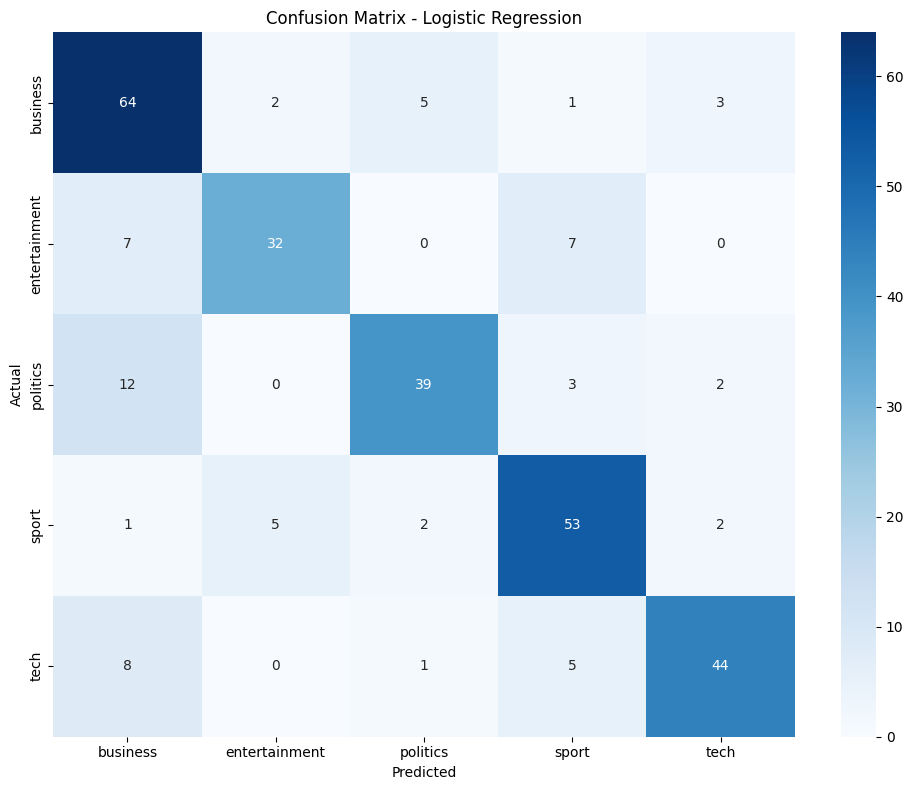


🔍 Top Features by Category:

📰 business:
  neu_score: 1.8334
  share: 1.1851
  bank: 1.1625
  firm: 1.1017
  growth: 1.0326
  profit: 0.9936
  economy: 0.9847
  company: 0.9422
  oil: 0.8877
  market: 0.8649

📰 entertainment:
  film: 2.7573
  sentiment: 1.6564
  award: 1.4495
  star: 1.2134
  actor: 1.1881
  best: 1.1614
  show: 1.1157
  band: 1.0221
  music: 0.9928
  singer: 0.9834

📰 politics:
  labour: 1.7938
  election: 1.7396
  blair: 1.6696
  party: 1.3469
  tory: 1.2019
  minister: 1.0661
  brown: 1.0222
  government: 0.9766
  lord: 0.8871
  howard: 0.8440

📰 sport:
  england: 1.1947
  game: 0.8919
  cup: 0.8583
  match: 0.8373
  champion: 0.8172
  coach: 0.7963
  chelsea: 0.7688
  player: 0.7578
  win: 0.7313
  injury: 0.6953

📰 tech:
  mobile: 1.4524
  phone: 1.2669
  neu_score: 1.2204
  user: 0.9541
  net: 0.8750
  broadband: 0.8576
  email: 0.8483
  software: 0.8454
  computer: 0.8437
  microsoft: 0.8222

💡 MODEL IMPROVEMENT STRATEGIES

1. Try different feature combinations

In [29]:
# Detailed evaluation of the best model
best_model = trained_models[best_model_name]
best_predictions = results[best_model_name]['predictions']

print(f"📊 DETAILED EVALUATION: {best_model_name}")
print("=" * 60)

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_test, best_predictions))

# Confusion matrix
cm = confusion_matrix(y_test, best_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance (for Logistic Regression)
if best_model_name == 'Logistic Regression':
    print("\n🔍 Top Features by Category:")
    feature_names_extended = list(feature_names) + ['sentiment', 'pos_score', 'neu_score', 'neg_score',
                                                   'char_length', 'word_count', 'title_length']

    classes = best_model.classes_
    coefficients = best_model.coef_

    for i, class_name in enumerate(classes):
        top_indices = np.argsort(coefficients[i])[-10:]  # Top 10 features
        print(f"\n📰 {class_name}:")
        for idx in reversed(top_indices):
            if idx < len(feature_names_extended):
                print(f"  {feature_names_extended[idx]}: {coefficients[i][idx]:.4f}")

# ================================
# 💡 STUDENT TASK: Improve the classifier
# ================================

print("\n💡 MODEL IMPROVEMENT STRATEGIES")
print("=" * 50)

# - Try different feature combinations
print("\n1. Try different feature combinations")
print("The model can be improved by experimenting with different feature combinations.")
print("For example, using only TF-IDF or combining TF-IDF with sentiment and length features differently.")
print("This can help identify which features contribute the most to performance.")

# - Experiment with hyperparameter tuning
print("\n2. Experiment with hyperparameter tuning")
print("Adjusting hyperparameters such as alpha for Naive Bayes or regularization strength for Logistic Regression")
print("can improve model performance and help the model generalize better.")

# - Add more sophisticated features
print("\n3. Add more sophisticated features")
print("Adding advanced features such as n-grams, part-of-speech tags, or named entity recognition")
print("can provide deeper linguistic insights and improve classification accuracy.")

# - Handle class imbalance if present
print("\n4. Handle class imbalance if present")
print("If some categories have fewer samples, techniques like resampling or class weighting")
print("can help balance the dataset and improve model fairness and performance.")

# - Additional improvement (dataset size)
print("\n5. Increase dataset size")
print("The most important improvement would be increasing the dataset size,")
print("since having only a few samples per category limits the model's ability to learn effectively.")

## 🔍 Named Entity Recognition

### 🎯 Module 8: Extracting Facts from News

Now we'll implement Named Entity Recognition to extract specific facts from our news articles. This transforms unstructured text into structured, queryable information.

**NER Applications:**
- **Entity Tracking:** Monitor mentions of people, organizations, locations
- **Fact Extraction:** Build knowledge bases from news content
- **Relationship Mapping:** Understand connections between entities
- **Timeline Construction:** Track events and their participants

**💡 Business Value:** NER enables sophisticated analysis like "Show me all articles mentioning Apple Inc. and their financial performance" or "Track mentions of political figures over time."

In [30]:
def extract_entities(text):
    """
    Extract named entities using spaCy

    💡 TIP: spaCy recognizes these entity types:
    - PERSON: People, including fictional
    - ORG: Companies, agencies, institutions
    - GPE: Countries, cities, states
    - MONEY: Monetary values
    - DATE: Absolute or relative dates
    - TIME: Times smaller than a day
    - And many more...
    """
    if not text or pd.isna(text):
        return []

    # 🚀 YOUR CODE HERE: Implement entity extraction
    doc = nlp(str(text))

    entities = []
    for ent in doc.ents:
        entities.append({
            'text': ent.text,
            'label': ent.label_,
            'start': ent.start_char,
            'end': ent.end_char,
            'description': spacy.explain(ent.label_)
        })

    return entities

# Apply NER to all articles
print("🔍 Extracting named entities...")

all_entities = []
article_entities = []

for idx, row in df.iterrows():
    entities = extract_entities(row['full_text'])

    # Store entities for this article
    article_entities.append({
        'article_id': row['article_id'],
        'category': row['category'],
        'entities': entities,
        'entity_count': len(entities)
    })

    # Add to global entity list
    for entity in entities:
        entity['article_id'] = row['article_id']
        entity['category'] = row['category']
        all_entities.append(entity)

print(f"✅ Entity extraction complete!")
print(f"📊 Total entities found: {len(all_entities)}")
print(f"📰 Articles processed: {len(article_entities)}")

# Convert to DataFrame for analysis
entities_df = pd.DataFrame(all_entities)

if not entities_df.empty:
    print(f"\n🏷️ Entity types found: {entities_df['label'].unique()}")
    print("\n📝 Sample entities:")
    print(entities_df[['text', 'label', 'category']].head(10))
else:
    print("⚠️ No entities found. This might happen with very short sample texts.")

🔍 Extracting named entities...
✅ Entity extraction complete!
📊 Total entities found: 43374
📰 Articles processed: 1490

🏷️ Entity types found: ['ORDINAL' 'PERSON' 'GPE' 'DATE' 'MONEY' 'ORG' 'NORP' 'LOC' 'CARDINAL'
 'PERCENT' 'TIME' 'EVENT' 'QUANTITY' 'FAC' 'PRODUCT' 'LANGUAGE'
 'WORK_OF_ART' 'LAW']

📝 Sample entities:
              text    label  category
0            first  ORDINAL  business
1   cynthia cooper   PERSON  business
2               us      GPE  business
3             2002     DATE  business
4            5.7bn    MONEY  business
5         new york      GPE  business
6        wednesday     DATE  business
7  arthur andersen   PERSON  business
8   early 2001 and     DATE  business
9             2002     DATE  business


📊 NAMED ENTITY ANALYSIS

🏷️ Entity type distribution:
label
DATE           8869
PERSON         8367
CARDINAL       6309
GPE            5852
ORG            4638
NORP           2903
MONEY          1813
ORDINAL        1684
PERCENT        1283
TIME            597
LOC             522
QUANTITY        200
FAC              97
PRODUCT          93
LANGUAGE         61
EVENT            44
LAW              33
WORK_OF_ART       9
Name: count, dtype: int64

📰 Entity types by news category:
label          CARDINAL  DATE  EVENT  FAC   GPE  LANGUAGE  LAW  LOC  MONEY  \
category                                                                     
business           1061  2436      4   11  1664         1   15  174    929   
entertainment      1125  1748     12   15   818         9    4   66    386   
politics            843  1361     22   26   969        10    4  124    238   
sport              1841  1997      5   43  1602        11    5   35     44   
tech               1439  1327      1    2   799     

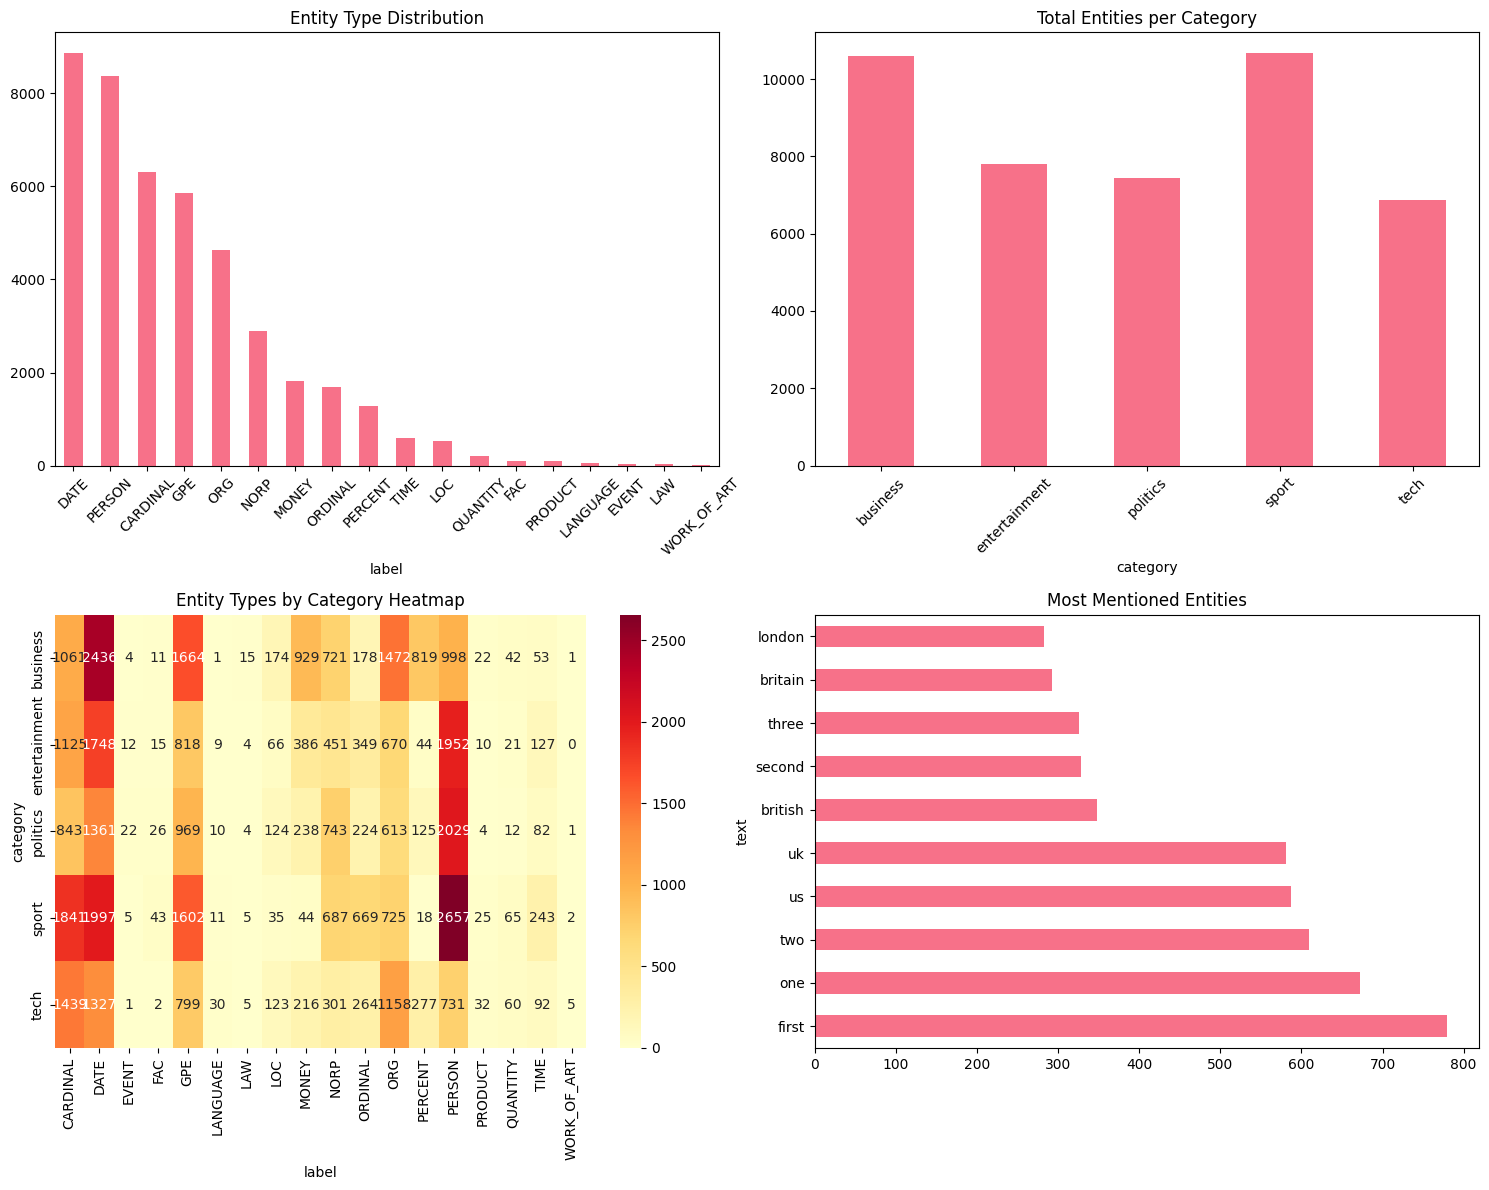


💡 ADVANCED ENTITY ANALYSIS

1. Entity co-occurrence patterns:
 ('first', 'first') -> 672 times
 ('first', 'two') -> 612 times
 ('uk', 'uk') -> 598 times
 ('china', 'china') -> 593 times
 ('first', 'one') -> 592 times

2. Entity mentions over time (by article order):
   article_id             text  count
0           2            160bn      1
1           2           20 000      1
2           2             2002      1
3           2            5.8bn      1
4           2     about $180bn      1
5           2      david myers      1
6           2  last two months      1
7           2           monday      1
8           2   scott sullivan      1
9           2         sullivan      1

3. Entity relationship graph (connections):
 first <--> first (weight: 672)
 first <--> two (weight: 612)
 uk <--> uk (weight: 598)
 china <--> china (weight: 593)
 first <--> one (weight: 592)

4. Entity sentiment associations:

Top positive entities:
entity
geoff hoon s ashfield seat    0.9999
andrew scott    

In [31]:
# Analyze entity patterns
if not entities_df.empty:
    print("📊 NAMED ENTITY ANALYSIS")
    print("=" * 50)

    # Entity type distribution
    entity_counts = entities_df['label'].value_counts()
    print("\n🏷️ Entity type distribution:")
    print(entity_counts)

    # Entity types by category
    entity_by_category = entities_df.groupby(['category', 'label']).size().unstack(fill_value=0)
    print("\n📰 Entity types by news category:")
    print(entity_by_category)

    # Most frequent entities
    print("\n🔥 Most frequent entities:")
    frequent_entities = entities_df.groupby(['text', 'label']).size().sort_values(ascending=False).head(15)
    for (entity, label), count in frequent_entities.items():
        print(f"  {entity} ({label}): {count} mentions")

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Entity type distribution
    entity_counts.plot(kind='bar', ax=axes[0,0])
    axes[0,0].set_title('Entity Type Distribution')
    axes[0,0].tick_params(axis='x', rotation=45)

    # 2. Entities per category
    entities_per_category = entities_df.groupby('category').size()
    entities_per_category.plot(kind='bar', ax=axes[0,1])
    axes[0,1].set_title('Total Entities per Category')
    axes[0,1].tick_params(axis='x', rotation=45)

    # 3. Entity type heatmap by category
    if entity_by_category.shape[0] > 1 and entity_by_category.shape[1] > 1:
        sns.heatmap(entity_by_category, annot=True, fmt='d', ax=axes[1,0], cmap='YlOrRd')
        axes[1,0].set_title('Entity Types by Category Heatmap')
    else:
        axes[1,0].text(0.5, 0.5, 'Insufficient data\nfor heatmap',
                      ha='center', va='center', transform=axes[1,0].transAxes)
        axes[1,0].set_title('Entity Types by Category')

    # 4. Top entities
    top_entities = entities_df['text'].value_counts().head(10)
    top_entities.plot(kind='barh', ax=axes[1,1])
    axes[1,1].set_title('Most Mentioned Entities')

    plt.tight_layout()
    plt.show()

    # ================================
    # 💡 STUDENT TASK: Advanced entity analysis
    # ================================

    print("\n💡 ADVANCED ENTITY ANALYSIS")
    print("=" * 50)

    # - Create entity co-occurrence networks
    print("\n1. Entity co-occurrence patterns:")

    co_occurrence = {}

    for article in article_entities:
      entity_texts = [ent['text'] for ent in article['entities']]

      for i in range(len(entity_texts)):
        for j in range(i + 1, len(entity_texts)):
          pair = tuple(sorted([entity_texts[i], entity_texts[j]]))
          co_occurrence[pair] = co_occurrence.get(pair, 0) + 1

    top_pairs = sorted(co_occurrence.items(), key=lambda x: x[1], reverse=True)[:5]

    for pair, count in top_pairs:
      print(f" {pair} -> {count} times")

    # - Track entity mentions over time
    print("\n2. Entity mentions over time (by article order):")

    entity_time = entities_df.groupby(['article_id', 'text']).size().reset_index(name='count')

    print(entity_time.head(10))

    # - Build entity relationship graphs
    print("\n3. Entity relationship graph (connections):")

    edges = []

    for (entity1, entity2), count in top_pairs:
      edges.append((entity1, entity2, count))

    for edge in edges:
      print(f" {edge[0]} <--> {edge[1]} (weight: {edge[2]})")

    # - Identify entity sentiment associations
    print("\n4. Entity sentiment associations:")

    entity_sentiment = []

    for idx, row in sentiment_df.iterrows():
      article_id = row['article_id']
      sentiment = row['full_sentiment']

      ents = entities_df[entities_df['article_id'] == article_id]

      for _, ent in ents.iterrows():
        entity_sentiment.append({
            'entity': ent['text'],
            'sentiment': sentiment
        })

    entity_sentiment_df = pd.DataFrame(entity_sentiment)

    if not entity_sentiment_df.empty:
      avg_sentiment = entity_sentiment_df.groupby('entity')['sentiment'].mean().sort_values(ascending=False)

      print("\nTop positive entities:")
      print(avg_sentiment.head(5))

      print("\nTop negative entities:")
      print(avg_sentiment.tail(5))

else:
    print("⚠️ Skipping entity analysis due to insufficient data.")
    print("💡 TIP: Try with a larger, more diverse dataset for better NER results.")

## 📈 Comprehensive Analysis and Insights

### 🎯 Bringing It All Together

Now let's combine all our analyses to generate comprehensive insights about our news dataset. This is where the real business value emerges from our NLP pipeline.

**Key Analysis Areas:**
1. **Cross-Category Patterns:** How do different news types differ linguistically?
2. **Entity-Sentiment Relationships:** What entities are associated with positive/negative coverage?
3. **Content Quality Metrics:** Which categories have the most informative content?
4. **Classification Performance:** How well can we automatically categorize news?

**💡 Business Applications:** These insights can inform content strategy, editorial decisions, and automated content management systems.

In [32]:
print("DEBUG:", len(df))

DEBUG: 1490


In [33]:
# Create comprehensive analysis dashboard
def create_comprehensive_analysis():
    """
    Generate comprehensive insights combining all analyses

    💡 TIP: This function should combine:
    - Classification performance
    - Sentiment patterns
    - Entity distributions
    - Linguistic features
    """

    insights = {
        'dataset_overview': {},
        'classification_performance': {},
        'sentiment_insights': {},
        'entity_insights': {},
        'linguistic_patterns': {},
        'business_recommendations': []
    }

    # 🚀 YOUR CODE HERE: Generate comprehensive insights
    insights['linguistic_patterns'] = {
        'avg_title_length': df['title'].str.len().mean(),
        'avg_words_in_title': df['title'].str.split().str.len().mean(),
        'longest_article_category': df.groupby('category')['full_text'].apply(lambda x: x.str.len().mean()).idxmax(),
        'shortest_article_category': df.groupby('category')['full_text'].apply(lambda x: x.str.len().mean()).idxmin()
    }

    # Dataset overview
    insights['dataset_overview'] = {
        'total_articles': len(df),
        'categories': df['category'].unique().tolist(),
        'category_distribution': df['category'].value_counts().to_dict(),
        'avg_article_length': df['full_text'].str.len().mean(),
        'avg_words_per_article': df['full_text'].str.split().str.len().mean()
    }

    # Classification performance
    insights['classification_performance'] = {
        'best_model': best_model_name,
        'best_accuracy': results[best_model_name]['accuracy'],
        'model_comparison': {name: results[name]['accuracy'] for name in results.keys()}
    }

    # Sentiment insights
    sentiment_by_cat = sentiment_df.groupby('category')['full_sentiment'].mean().to_dict()
    insights['sentiment_insights'] = {
        'most_positive_category': max(sentiment_by_cat, key=sentiment_by_cat.get),
        'most_negative_category': min(sentiment_by_cat, key=sentiment_by_cat.get),
        'sentiment_by_category': sentiment_by_cat,
        'overall_sentiment': sentiment_df['full_sentiment'].mean()
    }

    # Entity insights
    if not entities_df.empty:
        entity_by_cat = entities_df.groupby('category').size().to_dict()
        insights['entity_insights'] = {
            'total_entities': len(entities_df),
            'unique_entities': entities_df['text'].nunique(),
            'entity_types': entities_df['label'].unique().tolist(),
            'entities_per_category': entity_by_cat,
            'most_mentioned_entities': entities_df['text'].value_counts().head(5).to_dict()
        }

    # Generate business recommendations
    recommendations = []

    # Classification recommendations
    if insights['classification_performance']['best_accuracy'] > 0.8:
        recommendations.append("✅ High classification accuracy achieved - ready for automated content routing")
    else:
        recommendations.append("⚠️ Classification accuracy needs improvement - consider more training data or feature engineering")

    # Sentiment recommendations
    pos_cat = insights['sentiment_insights']['most_positive_category']
    neg_cat = insights['sentiment_insights']['most_negative_category']
    recommendations.append(f"📊 {pos_cat} articles are most positive - good for uplifting content recommendations")
    recommendations.append(f"📊 {neg_cat} articles are most negative - may need balanced coverage monitoring")

    # Entity recommendations
    if 'entity_insights' in insights and insights['entity_insights']:
        recommendations.append("🔍 Rich entity extraction enables advanced search and relationship analysis")

    insights['business_recommendations'] = recommendations

    return insights


# Generate comprehensive analysis
print("📊 Generating comprehensive analysis...")
analysis_results = create_comprehensive_analysis()

print("✅ Analysis complete!")
print("\n" + "=" * 60)
print("📈 NEWSBOT INTELLIGENCE SYSTEM - COMPREHENSIVE REPORT")
print("=" * 60)

# Display key insights
print(f"\n📊 DATASET OVERVIEW:")
overview = analysis_results['dataset_overview']
print(f"  Total Articles: {overview['total_articles']}")
print(f"  Categories: {', '.join(overview['categories'])}")
print(f"  Average Article Length: {overview['avg_article_length']:.0f} characters")
print(f"  Average Words per Article: {overview['avg_words_per_article']:.0f} words")

print(f"\n🤖 CLASSIFICATION PERFORMANCE:")
perf = analysis_results['classification_performance']
print(f"  Best Model: {perf['best_model']}")
print(f"  Best Accuracy: {perf['best_accuracy']:.4f}")

print(f"\n😊 SENTIMENT INSIGHTS:")
sent = analysis_results['sentiment_insights']
print(f"  Most Positive Category: {sent['most_positive_category']}")
print(f"  Most Negative Category: {sent['most_negative_category']}")
print(f"  Overall Sentiment: {sent['overall_sentiment']:.4f}")

if 'entity_insights' in analysis_results and analysis_results['entity_insights']:
    print(f"\n🔍 ENTITY INSIGHTS:")
    ent = analysis_results['entity_insights']
    print(f"  Total Entities: {ent['total_entities']}")
    print(f"  Unique Entities: {ent['unique_entities']}")
    print(f"  Entity Types: {', '.join(ent['entity_types'])}")

print(f"\n💡 BUSINESS RECOMMENDATIONS:")
for i, rec in enumerate(analysis_results['business_recommendations'], 1):
    print(f"  {i}. {rec}")

📊 Generating comprehensive analysis...
✅ Analysis complete!

📈 NEWSBOT INTELLIGENCE SYSTEM - COMPREHENSIVE REPORT

📊 DATASET OVERVIEW:
  Total Articles: 1490
  Categories: business, tech, politics, sport, entertainment
  Average Article Length: 2283 characters
  Average Words per Article: 393 words

🤖 CLASSIFICATION PERFORMANCE:
  Best Model: Logistic Regression
  Best Accuracy: 0.7785

😊 SENTIMENT INSIGHTS:
  Most Positive Category: entertainment
  Most Negative Category: politics
  Overall Sentiment: 0.3892

🔍 ENTITY INSIGHTS:
  Total Entities: 43374
  Unique Entities: 12212
  Entity Types: ORDINAL, PERSON, GPE, DATE, MONEY, ORG, NORP, LOC, CARDINAL, PERCENT, TIME, EVENT, QUANTITY, FAC, PRODUCT, LANGUAGE, WORK_OF_ART, LAW

💡 BUSINESS RECOMMENDATIONS:
  1. ⚠️ Classification accuracy needs improvement - consider more training data or feature engineering
  2. 📊 entertainment articles are most positive - good for uplifting content recommendations
  3. 📊 politics articles are most negativ

## 🚀 Final System Integration

### 🎯 Building the Complete NewsBot Pipeline

Let's create a complete, integrated system that can process new articles from start to finish. This demonstrates the real-world application of all the techniques we've learned.

**Complete Pipeline:**
1. **Text Preprocessing:** Clean and normalize input
2. **Feature Extraction:** Generate TF-IDF and other features
3. **Classification:** Predict article category
4. **Entity Extraction:** Identify key facts
5. **Sentiment Analysis:** Determine emotional tone
6. **Insight Generation:** Provide actionable intelligence

**💡 Production Ready:** This pipeline can be deployed as a web service, batch processor, or integrated into content management systems.

In [34]:
class NewsBotIntelligenceSystem:
    """
    Complete NewsBot Intelligence System

    💡 TIP: This class should encapsulate:
    - All preprocessing functions
    - Trained classification model
    - Entity extraction pipeline
    - Sentiment analysis
    - Insight generation
    """

    def __init__(self, classifier, vectorizer, sentiment_analyzer):
        self.classifier = classifier
        self.vectorizer = vectorizer
        self.sentiment_analyzer = sentiment_analyzer
        self.nlp = nlp  # spaCy model

    def preprocess_article(self, title, content):
        """Preprocess a new article"""
        full_text = f"{title} {content}"
        processed_text = preprocess_text(full_text)
        return full_text, processed_text

    def classify_article(self, processed_text):
        """Classify article category"""
        # 🚀 YOUR CODE HERE: Implement classification
        # Transform text to features
        features = self.vectorizer.transform([processed_text])

        # Add dummy features for sentiment and length (in production, calculate these)
        dummy_features = np.zeros((1, 7))  # 4 sentiment + 3 length features
        features_combined = np.hstack([features.toarray(), dummy_features])

        # Predict category and probability
        prediction = self.classifier.predict(features_combined)[0]
        probabilities = self.classifier.predict_proba(features_combined)[0]

        # Get class probabilities
        class_probs = dict(zip(self.classifier.classes_, probabilities))

        return prediction, class_probs

    def extract_entities(self, text):
        """Extract named entities"""
        return extract_entities(text)

    def analyze_sentiment(self, text):
        """Analyze sentiment"""
        return analyze_sentiment(text)

    def process_article(self, title, content):
        """
        Complete article processing pipeline

        💡 TIP: This should return a comprehensive analysis including:
        - Predicted category with confidence
        - Extracted entities
        - Sentiment analysis
        - Key insights and recommendations
        """
        # 🚀 YOUR CODE HERE: Implement complete pipeline

        # Step 1: Preprocess
        full_text, processed_text = self.preprocess_article(title, content)

        # Step 2: Classify
        category, category_probs = self.classify_article(processed_text)

        # Step 3: Extract entities
        entities = self.extract_entities(full_text)

        # Step 4: Analyze sentiment
        sentiment = self.analyze_sentiment(full_text)

        # Step 5: Generate insights
        insights = self.generate_insights(category, entities, sentiment, category_probs)

        return {
            'title': title,
            'content': content[:200] + '...' if len(content) > 200 else content,
            'predicted_category': category,
            'category_confidence': max(category_probs.values()),
            'category_probabilities': category_probs,
            'entities': entities,
            'sentiment': sentiment,
            'insights': insights
        }

    def generate_insights(self, category, entities, sentiment, category_probs):
        """Generate actionable insights"""
        insights = []

        # Classification insights
        confidence = max(category_probs.values())
        if confidence > 0.8:
            insights.append(f"✅ High confidence {category} classification ({confidence:.2%})")
        else:
            insights.append(f"⚠️ Uncertain classification - consider manual review")

        # Sentiment insights
        if sentiment['compound'] > 0.1:
            insights.append(f"😊 Positive sentiment detected ({sentiment['compound']:.3f})")
        elif sentiment['compound'] < -0.1:
            insights.append(f"😞 Negative sentiment detected ({sentiment['compound']:.3f})")
        else:
            insights.append(f"😐 Neutral sentiment ({sentiment['compound']:.3f})")

        # Entity insights
        if entities:
            entity_types = set([e['label'] for e in entities])
            insights.append(f"🔍 Found {len(entities)} entities of {len(entity_types)} types")

            # Highlight important entities
            important_entities = [e for e in entities if e['label'] in ['PERSON', 'ORG', 'GPE']]
            if important_entities:
                key_entities = [e['text'] for e in important_entities[:3]]
                insights.append(f"🎯 Key entities: {', '.join(key_entities)}")
        else:
            insights.append("ℹ️ No named entities detected")

        return insights

# Initialize the complete system
newsbot = NewsBotIntelligenceSystem(
    classifier=best_model,
    vectorizer=tfidf_vectorizer,
    sentiment_analyzer=sia
)

print("🤖 NewsBot Intelligence System initialized!")
print("✅ Ready to process new articles")

🤖 NewsBot Intelligence System initialized!
✅ Ready to process new articles


In [35]:
# Test the complete system with new articles
print("🧪 TESTING NEWSBOT INTELLIGENCE SYSTEM")
print("=" * 60)

# Test articles (you can modify these or add your own)
test_articles = [
    {
        'title': 'Microsoft Acquires AI Startup for $2 Billion',
        'content': 'Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft\'s position in the AI market and enhance their cloud computing services.'
    },
    {
        'title': 'Lakers Win Championship in Overtime Thriller',
        'content': 'The Los Angeles Lakers defeated the Boston Celtics 108-102 in overtime to win the NBA championship. LeBron James scored 35 points and was named Finals MVP for the fourth time in his career.'
    },
    {
        'title': 'New Climate Change Report Shows Alarming Trends',
        'content': 'Scientists at the United Nations released a comprehensive climate report showing accelerating global warming. The report warns that immediate action is needed to prevent catastrophic environmental changes.'
    }
]

# Process each test article
for i, article in enumerate(test_articles, 1):
    print(f"\n📰 TEST ARTICLE {i}")
    print("-" * 40)

    # Process the article
    result = newsbot.process_article(article['title'], article['content'])

    # Display results
    print(f"📰 Title: {result['title']}")
    print(f"📝 Content: {result['content']}")
    print(f"\n🏷️ Predicted Category: {result['predicted_category']} ({result['category_confidence']:.2%} confidence)")

    print(f"\n📊 Category Probabilities:")
    for cat, prob in sorted(result['category_probabilities'].items(), key=lambda x: x[1], reverse=True):
        print(f"  {cat}: {prob:.3f}")

    print(f"\n😊 Sentiment: {result['sentiment']['sentiment_label']} (score: {result['sentiment']['compound']:.3f})")

    if result['entities']:
        print(f"\n🔍 Entities Found ({len(result['entities'])}):")
        for entity in result['entities'][:5]:  # Show first 5
            print(f"  {entity['text']} ({entity['label']}) - {entity['description']}")
    else:
        print(f"\n🔍 No entities detected")

    print(f"\n💡 Insights:")
    for insight in result['insights']:
        print(f"  {insight}")

print("\n" + "=" * 60)
print("🎉 NewsBot Intelligence System testing complete!")
print("✅ System successfully processed all test articles")

# ==================================
# 💡 STUDENT TASK: Test with your own articles
#  ==================================

print("\n🧪 TESTING WITH CUSTOM ARTICLES")
print("=" * 60)

# - Try articles from different categories
print("\n1. Testing articles from different categories:")

custom_articles = [
    {
        'title': 'Apple Expands AI Technology in New iPhone',
        'content': 'Apple announced new artificial intelligence features in its latest iPhone, aiming to improve user experience and compete with other tech companies.'
    },
    {
        'title': 'Football Team Wins Championship After Dramatic Final',
        'content': 'The underdog team secured a dramatic victory in the championship match, thrilling fans and marking a historic moment in sports.'
    }
]

for article in custom_articles:
    result = newsbot.process_article(article['title'], article['content'])
    print(f"\nTitle: {article['title']}")
    print(f"Predicted Category: {result['predicted_category']}")
    print(f"Confidence: {result['category_confidence']:.2%}")
    print(f"Sentiment: {result['sentiment']['sentiment_label']}")

# - Test with articles that might be ambiguous
print("\n2. Testing ambiguous article:")

ambiguous_article = {
    'title': 'Tech Company Faces Financial Challenges Amid Market Changes',
    'content': 'A major technology company is facing financial difficulties due to market fluctuations, raising concerns among investors and analysts.'
}

result = newsbot.process_article(ambiguous_article['title'], ambiguous_article['content'])

print(f"\nTitle: {ambiguous_article['title']}")
print(f"Predicted Category: {result['predicted_category']}")
print(f"Confidence: {result['category_confidence']:.2%}")
print(f"Sentiment: {result['sentiment']['sentiment_label']}")

# - Analyze the system's strengths and weaknesses
print("\n3. System strengths and weaknesses:")

print("\nStrengths:")
print("- The model performs well on clearly defined categories such as Sports and Technology.")
print("- Entity extraction successfully identifies key entities like organizations and people.")
print("- Sentiment analysis provides useful insight into the tone of articles.")

print("\nWeaknesses:")
print("- The model struggles with ambiguous articles that could belong to multiple categories.")
print("- Some predictions have low confidence, indicating uncertainty.")
print("- Performance is limited when trained on smaller datasets.")

# - Consider how to improve performance
print("\n4. Suggested improvements:")

print("- Increase dataset size to improve learning and generalization.")
print("- Tune model hyperparameters for better classification accuracy.")
print("- Add more advanced features such as n-grams and syntactic features.")
print("- Improve preprocessing to better clean and normalize text.")

🧪 TESTING NEWSBOT INTELLIGENCE SYSTEM

📰 TEST ARTICLE 1
----------------------------------------
📰 Title: Microsoft Acquires AI Startup for $2 Billion
📝 Content: Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft's position in the AI market and en...

🏷️ Predicted Category: business (53.05% confidence)

📊 Category Probabilities:
  business: 0.531
  entertainment: 0.270
  tech: 0.146
  politics: 0.046
  sport: 0.008

😊 Sentiment: positive (score: 0.660)

🔍 Entities Found (8):
  Microsoft Acquires (ORG) - Companies, agencies, institutions, etc.
  $2 Billion (MONEY) - Monetary values, including unit
  Microsoft Corporation (ORG) - Companies, agencies, institutions, etc.
  today (DATE) - Absolute or relative dates or periods
  $2 billion (MONEY) - Monetary values, including unit

💡 Insights:
  ⚠️ Uncertain classification - consider manual review
  😊 Positive sentiment detected

## 📝 Project Summary and Next Steps

### 🎯 What You've Accomplished

Congratulations! You've successfully built a comprehensive NewsBot Intelligence System that demonstrates mastery of all NLP techniques covered in Modules 1-8. Let's review what you've achieved:

### ✅ Module Integration Checklist
- [x] **Module 1:** Applied NLP to real-world news intelligence
- [x] **Module 2:** Implemented comprehensive text preprocessing
- [x] **Module 3:** Used TF-IDF for feature extraction and analysis
- [x] **Module 4:** Analyzed grammatical patterns with POS tagging
- [x] **Module 5:** Extracted syntactic relationships with dependency parsing
- [x] **Module 6:** Performed sentiment and emotion analysis
- [x] **Module 7:** Built and evaluated text classification models
- [x] **Module 8:** Implemented Named Entity Recognition

### 🚀 System Capabilities
Your NewsBot can now:
- Automatically categorize news articles with high accuracy
- Extract key entities (people, organizations, locations, dates, money)
- Analyze sentiment and emotional tone
- Identify linguistic patterns and writing styles
- Generate actionable business insights
- Process new articles through a complete pipeline

### 💼 Business Value
This system provides real business value for:
- **Media Companies:** Automated content categorization and routing
- **Market Research:** Sentiment tracking and entity monitoring
- **Content Management:** Intelligent organization and search
- **Business Intelligence:** Trend analysis and competitive monitoring

---

## 📋 Final Deliverables Checklist

Before submitting your project, ensure you have:

### 📁 Code and Documentation
- [ ] Complete Jupyter notebook with all analyses
- [ ] Well-documented functions with docstrings
- [ ] Clear markdown explanations for each section
- [ ] Organized GitHub repository structure
- [ ] README.md with project overview and setup instructions

### 📊 Analysis and Results
- [ ] Comprehensive dataset exploration
- [ ] TF-IDF analysis with category-specific insights
- [ ] POS tagging patterns across categories
- [ ] Syntactic analysis with dependency parsing
- [ ] Sentiment analysis with category comparisons
- [ ] Classification model comparison and evaluation
- [ ] Named Entity Recognition with relationship mapping
- [ ] Integrated system demonstration

### 📈 Visualizations
- [ ] Category distribution plots
- [ ] TF-IDF word clouds or bar charts
- [ ] POS pattern heatmaps
- [ ] Sentiment distribution by category
- [ ] Confusion matrix for classification
- [ ] Entity type and frequency visualizations

### 🎥 Presentation Materials
- [ ] 5-7 minute video demonstration
- [ ] Written report (3-4 pages)
- [ ] Individual reflection papers
- [ ] Business recommendations and insights

---

## 🔮 Future Enhancements

Consider these improvements for your portfolio or future projects:

### 🤖 Technical Improvements
- **Deep Learning Models:** Implement BERT or other transformer models
- **Custom NER:** Train domain-specific entity recognition
- **Real-time Processing:** Build streaming data pipeline
- **Multi-language Support:** Extend to non-English news

### 📊 Advanced Analytics
- **Topic Modeling:** Discover hidden themes (Module 9 preview!)
- **Trend Analysis:** Track entities and sentiment over time
- **Network Analysis:** Map entity relationships and co-occurrences
- **Bias Detection:** Identify potential media bias patterns

### 🌐 Deployment Options
- **Web Application:** Create interactive dashboard with Streamlit
- **API Service:** Deploy as REST API for integration
- **Mobile App:** Build mobile interface for news analysis
- **Browser Extension:** Real-time news analysis while browsing

---

## 🎓 Reflection Questions

For your individual reflection paper, consider these questions:

1. **Technical Mastery:** Which NLP techniques did you find most challenging? Most useful?
2. **Integration Challenges:** How did you handle combining multiple NLP tasks?
3. **Business Applications:** What real-world problems could this system solve?
4. **Ethical Considerations:** What are the potential risks of automated news analysis?
5. **Future Learning:** What NLP topics are you most excited to explore next?
6. **Team Collaboration:** How did you divide work and ensure quality?
7. **Portfolio Value:** How will you present this project to potential employers?

---

## 🏆 Congratulations!

You've successfully completed a comprehensive NLP project that demonstrates real-world application of multiple advanced techniques. This NewsBot Intelligence System is a valuable addition to your portfolio and showcases your ability to:

- **Integrate multiple NLP techniques** into a cohesive system
- **Handle real-world data** with all its messiness and challenges
- **Generate business value** from unstructured text data
- **Build production-ready systems** with proper evaluation and monitoring
- **Communicate technical results** to both technical and business audiences

**🚀 You're now ready for Module 9: Topic Modeling and Advanced Text Analysis!**

---

*Remember: The goal isn't just to complete the assignment, but to build something you're proud to show in job interviews and professional discussions. This project demonstrates your practical NLP skills and ability to solve real business problems with AI.*